# Case Técnico — Cientista de Dados
## Compras públicas de medicamentos: qualidade, preços e indicadores

**Base:** `compras-gov.csv` — 2.706 itens de compra, classe CATMAT 6505 (Drogas e Medicamentos), dez/2021 a jul/2025.

---

### Como este documento está organizado

| Etapa | Onde está |
|---|---|
| **1 — Proposta de coleta** | `docs/01_arquitetura_coleta.md` (resumo na seção 1 abaixo) |
| **2 — Compreensão e qualidade** | seção 2 deste notebook |
| **3 — Preparação** | seção 3 |
| **4 — Análise** | seção 4 (três perguntas + análise temporal) |
| **5 — Indicadores** | seção 5 |
| **6 — Reprodutibilidade** | `README.md` + seção 6 |
| Decisões metodológicas | `docs/02_decisoes_metodologicas.md` |

O código de produção vive em `src/` e é **importado** aqui, não repetido:
`ingestao.py` (leitura) → `qualidade.py` (diagnóstico) → `preparacao.py`
(tratamento) → `analise.py` (análise) → `indicadores.py`. Essa separação é o
que atende ao requisito da Etapa 6 e o que permite testar cada camada
isoladamente.

---
## Sobre este relatório

Este notebook documenta a análise completa: os problemas encontrados nos
dados, como foram tratados, três perguntas sobre os preços pagos e quatro
indicadores propostos para acompanhar isso de forma contínua. A seção
seguinte resume tudo em linguagem simples; a partir da seção 2, o texto entra
no detalhe técnico e no código.

<!-- celula-comunicacao -->

## Resumo, em linguagem simples

**Os dados são confiáveis?** Em parte. A base passa em qualquer verificação
automática — sem células vazias, sem linhas duplicadas, todos os CNPJs
válidos. O problema aparece quando se olha o que cada dado significa: alguns
preços são na verdade o valor do lote inteiro (não do item), a mesma empresa
aparece com nomes diferentes, e existem três formas distintas de marcar
"sem informação" no mesmo arquivo — uma delas é um espaço em branco,
invisível numa tabela comum. Nada foi apagado por causa disso: cada problema
virou uma marcação, e as exclusões só acontecem no momento de calcular algo
específico. Do total de itens, 90,8% entram na comparação de preços.

**O preço do mesmo remédio varia muito?** Sim, cerca de duas vezes entre o
comprador mais barato e o mais caro. E o mais revelador: 86% dessa
diferença acontece dentro do mesmo estado, entre municípios vizinhos — não é
custo de frete ou diferença regional, é diferença na capacidade de negociar.

**Comprar mais sai mais barato?** Sim, mas menos do que se imagina:
multiplicar o volume por dez baixa o preço uns 14%, não pela metade. Os
consórcios intermunicipais de saúde pagam cerca de 20% abaixo da mediana, o
que é a evidência mais concreta de que juntar compras funciona.

**A forma de contratar importa?** Sim: comprar por dispensa de licitação, em
vez de pregão, custa em média 18% mais caro no mesmo item. No AAS, a
diferença bruta chega a 70%.

**Falta concorrência entre fornecedores?** Não — cada medicamento tem entre
268 e 288 grupos econômicos diferentes fornecendo, e nenhum mercado está
concentrado.

Juntando as três últimas respostas: os preços variam bastante, a escala
explica só uma parte pequena dessa variação, e não é falta de concorrência.
Por eliminação, o problema está em como cada comprador negocia, não em quem
vende — e essa é uma notícia melhor do que parece, porque dá pra resolver com
informação (mostrar o preço de referência pro gestor, juntar compras via
consórcio, evitar dispensa onde a demanda é previsível), sem precisar de
fiscalização pesada.

Em reais: o que foi pago acima da mediana do próprio grupo soma R$ 617 mil;
acima do percentil 10, R$ 4,2 milhões — sobre R$ 49,4 milhões homologados
nesses três medicamentos. São valores de referência, não uma meta: parte da
diferença é volume legítimo, parte é urgência real.


<!-- celula-comunicacao -->

As figuras desta seção vêm de `src/graficos.py`, separado de `analise.py`
porque servem para propósitos diferentes: lá, as figuras ajudam a verificar
um resultado; aqui, ajudam a explicá-lo. Nenhuma delas recalcula nada — todas
usam os números já calculados na análise.

---
## 0. Ambiente e dependências

In [1]:
import sys, platform, logging, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import scipy
import statsmodels
from IPython.display import Image, display, Markdown

# O notebook é executado da raiz do repositório
if str(Path.cwd().name) == "notebooks":
    sys.path.insert(0, str(Path.cwd().parent))
    import os; os.chdir(Path.cwd().parent)

from src import ingestao, qualidade, preparacao, analise, indicadores, config

warnings.filterwarnings("ignore", category=FutureWarning)
logging.basicConfig(level=logging.WARNING)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

print(f"Python       {platform.python_version()}")
for m in (pd, np, scipy, statsmodels, matplotlib):
    print(f"{m.__name__:12s} {m.__version__}")

Python       3.12.3
pandas       3.0.2
numpy        2.4.4
scipy        1.17.1
statsmodels  0.15.0
matplotlib   3.10.8


---
# Etapa 1 — Proposta de coleta de dados

O enunciado pede uma arquitetura para consumir APIs públicas em geral — o
Compras.gov é só o exemplo usado no case, não o alvo exclusivo. Por isso, a
proposta abaixo não depende de nenhum detalhe específico dessa API. O jeito
como ela se aplica ao Compras.gov real, usando o índice do Swagger, está
isolado no anexo ao final do documento: se o exemplo fosse outra fonte, só o
anexo mudaria.

A proposta completa está em **[`docs/01_arquitetura_coleta.md`](../docs/01_arquitetura_coleta.md)**,
com fluxograma, tabelas de decisão e política de erro por código HTTP. O
esqueleto comentado do coletor está em `src/coleta.py` (não executado) —
escrito com `Protocol` para cliente HTTP e armazenamento, sem depender de
biblioteca ou API específica.

### Resumo das decisões

**Três características da fonte determinam o desenho** — e as três foram
descobertas na análise da própria base, não assumidas:

1. **A fonte é mutável retroativamente.** 68% dos itens têm
   `dataHoraAtualizacaoItem` mais de um ano após `dataCompra`, e três
   registros aparecem em duas versões com fornecedor diferente.
   → O campo de controle da coleta tem de ser a data de **atualização**, não
   a data do fato; e o histórico precisa ser versionado (SCD tipo 2), para
   que retificações sejam auditáveis em vez de silenciosas.
2. **O dado passou por intermediários.** `codigoMunicipio` formatado como
   decimal, a string literal `'nan'` (um NaN de Python serializado) e resíduo
   de JavaScript em `marca` — três evidências convergentes.
   → Consumir a API diretamente e **preservar o payload bruto**.
3. **Coleta longa em API pública instável.**
   → Checkpoint por página, retry com backoff exponencial e *jitter*,
   circuit breaker, e rate limit no próprio cliente (não reagir ao 429).

**Arquitetura:** medalhão em três camadas.

- **Bronze** — JSON original comprimido, *append-only*, com versionamento de
  objeto e manifesto por execução (hash, parâmetros, contagens). Dado
  público que muda sem aviso só é auditável se alguém guardou a versão
  anterior.
- **Silver** — SCD tipo 2 por `idItemCompra`, carregado por **MERGE
  idempotente**. Reexecutar qualquer dia é seguro, o que torna o backfill
  trivial e permite sobreposição deliberada da janela de coleta.
- **Gold** — fato + dimensões + os indicadores da Etapa 5.

**Duas trilhas de coleta:** incremental diária (últimos 7 dias de
atualização, com folga sobre o watermark) e reconciliação mensal (24 meses),
que recupera retificações fora da janela.

**Schema drift:** contrato declarado em `config.SCHEMA_ESPERADO` e verificado
a cada carga. Campo novo é acolhido no bronze e alertado; campo removido
**falha** a promoção para silver; domínios (`modalidade`, etc.) são coletados
dos endpoints de referência e versionados como dimensão datada, nunca fixados
no código.

**Validação em três níveis:** completude da coleta (total lido = total
declarado pela API; nenhuma lacuna de página ou de mês), integridade
estrutural (unicidade de chaves, taxa de falha de parsing) e plausibilidade
(as 27 regras da seção 2). O que se monitora não é a taxa absoluta — 6,6% de
preços implausíveis é característica conhecida da fonte — mas a sua
**variação**.

<!-- celula-etapa1 -->

### O desenho em uma figura

O diagrama abaixo é a proposta inteira em uma imagem: a fonte à esquerda, as
três camadas de dado na linha de cima, e os três mecanismos de controle na
linha de baixo.

O dado bruto entra e nunca é alterado. Toda interpretação acontece na
promoção entre camadas, e cada promoção só ocorre se passar pelo contrato de
schema e pelos três níveis de validação. É isso que permite corrigir uma
regra errada sem recoletar quatro anos de dados.

Note onde as falhas param o processo: uma validação reprovada bloqueia a
**promoção**, nunca a **gravação no bronze**. Dado que chegou é dado que fica
guardado, mesmo que ainda não seja utilizável.


In [ ]:
from src import graficos

display(Image(str(graficos.diagrama_coleta())))

<!-- celula-etapa1 -->

### Mapa de cobertura do enunciado

Todas as decisões abaixo são genéricas — nenhuma depende de qual API está por
trás. O Compras.gov só aparece como exemplo aplicado, no anexo do documento.

| O que a Etapa 1 pede | Decisão em uma linha |
|---|---|
| estratégia de coleta e atualização | duas trilhas: incremental diária por marca d'água + reconciliação periódica |
| paginação e limites de requisição | paginação por chave onde houver, partições curtas onde não; vazão controlada no cliente |
| falhas, interrupções, indisponibilidade | resposta por classe de erro, recuo exponencial com *jitter*, disjuntor, retomada por checkpoint |
| armazenamento do bruto e histórico | payload original em armazenamento imutável (WORM) + SCD tipo 2 na camada tratada |
| alterações na estrutura dos dados | contrato de schema versionado, com política declarada por tipo de mudança |
| validação de completude e consistência | três níveis: a coleta rodou / o dado é válido / é plausível vs a carga anterior |
| execução, monitoramento e erros | log estruturado com id de execução, métricas por rodada, alertas em três severidades |

### O exemplo aplicado (anexo)

O documento fecha com um anexo curto que aplica esse desenho genérico ao
exemplo fornecido pelo case, usando o índice real do Swagger do Compras.gov
(`/v3/api-docs`): identifica o endpoint provável de origem
(`GET /modulo-pesquisa-preco/2_consultarMaterialDetalhe`), destaca a
existência de uma variante em lote (`_CSV`) — achado que ilustra um princípio
geral, não uma peculiaridade — e lista o que o índice confirma ou deixa em
aberto. Nenhuma decisão das seções anteriores depende desse anexo; se o
exemplo fosse outra API, apenas ele mudaria. Detalhes na §"Anexo" de
[`docs/01_arquitetura_coleta.md`](../docs/01_arquitetura_coleta.md).


<!-- celula-etapa1-pseudo -->

### A rotina diária em pseudocódigo

O enunciado admite texto, pseudocódigo, fluxograma ou desenho. Já há texto e
desenho; segue o pseudocódigo da execução diária, que é onde as sete
exigências se encontram na prática.

```
executar_coleta_diaria(data_execucao):

    id_exec ← uuid()                                  # correlaciona todo o log
    marca   ← estado.ler_marca_dagua()                # dataHoraAtualizacaoItem
    desde   ← marca − 48h                             # sobreposição deliberada

    para cada particao em gerar_particoes(desde, data_execucao):

        se estado.concluida(particao, id_exec):        # idempotência
            continuar                                  # retomada sem repetir

        pagina ← estado.ultimo_checkpoint(particao) ou primeira

        enquanto pagina existe:

            limitador.aguardar_token()                 # vazão < limite da API
            se disjuntor.aberto():                     # fonte fora do ar
                falhar_particao(particao); interromper

            tentativa ← 0
            repetir:
                resposta ← http.get(endpoint, params(particao, pagina))

                escolher resposta.status:
                  200        → seguir
                  429        → esperar(Retry-After); tentativa += 1
                  502,503,504→ esperar(2^tentativa + jitter); tentativa += 1
                  400,404    → ErroDefinitivo        # defeito nosso: NÃO repetir
                  401,403    → interromper tudo + alerta crítico
            até resposta.status = 200 ou tentativa = MAX

            se tentativa = MAX:
                disjuntor.registrar_falha()
                falhar_particao(particao); interromper

            # BRONZE — grava antes de interpretar qualquer coisa
            chave ← hash(particao, pagina, params)     # nome determinístico
            armazenamento.gravar_worm(chave, resposta.corpo_original)
            armazenamento.gravar_manifesto(chave, {
                url, params, status, n_registros,
                sha256(resposta.corpo_original), id_exec, agora()
            })

            estado.salvar_checkpoint(particao, pagina)
            pagina ← proxima_pagina(resposta)          # keyset, se disponível

        estado.marcar_concluida(particao, id_exec)

    # ---- promoção BRONZE → PRATA: só aqui o dado é interpretado ----

    lote ← ler_bronze(id_exec)

    validar_contrato_schema(lote)                      # falha ⇒ PARA aqui
    metricas ← validar_tres_niveis(lote, carga_anterior)
    se metricas.bloqueante:
        alertar(critico); PARA                         # bronze permanece salvo

    MERGE lote EM prata POR idItemCompra               # SCD tipo 2, idempotente

    estado.gravar_marca_dagua(max(lote.dataHoraAtualizacaoItem))
    publicar_metricas(id_exec, metricas)
```

**Três detalhes que a leitura rápida esconde**, e que são o essencial do
desenho:

1. **A gravação no bronze vem antes de qualquer validação.** Se o contrato de
   schema falhar, o processo para — mas o dado coletado já está salvo. Nunca se
   perde uma coleta por causa de uma regra de interpretação errada.
2. **`chave ← hash(...)` é o que torna a repetição segura.** Reexecutar a mesma
   partição sobrescreve o mesmo objeto com conteúdo idêntico. É isso que
   permite recuperar de qualquer falha simplesmente tentando de novo, sem
   raciocinar sobre o que ficou escrito pela metade.
3. **A marca d'água só avança no fim.** Se o processo morrer no meio, a próxima
   execução recomeça da marca antiga e reprocessa — o que é inofensivo, pela
   propriedade anterior. Avançá-la antes criaria uma janela de perda
   silenciosa.

A rotina mensal de reconciliação é mais simples: varre uma janela móvel de 24
meses, compara contagem e soma de valores por partição entre a fonte e a
camada prata, e reporta divergências. Ela existe para pegar o que a
incremental não consegue ver — registros alterados na fonte **sem** atualização
do campo de timestamp.


In [ ]:
import inspect
from src import coleta

# O esqueleto comentado das partes não triviais está em src/coleta.py.
# Exibimos a política de erro por classe, que é o coração do item
# "tratamento de falhas" do enunciado. O módulo NÃO é executado.
print(inspect.getsource(coleta.requisitar))

---
# Etapa 2 — Compreensão e qualidade dos dados

## 2.1 Leitura e contrato de schema

A leitura preserva fidelidade ao original: **tudo como texto**, com
`keep_default_na=False`. As duas opções são deliberadas e explicadas no
código de `src/ingestao.py`. A mais importante: a fonte grava a **string
literal `"NA"`** como sentinela de ausência, e o comportamento padrão do
pandas a converteria em `NaN` antes de qualquer contagem — fazendo a base
parecer completa.

In [2]:
df_bruto, meta = ingestao.ler_bruto()
print(f"Dimensões : {df_bruto.shape[0]:,} linhas x {df_bruto.shape[1]} colunas")
print(f"SHA-256   : {meta['sha256'][:32]}...")
print(f"Contrato  : {meta['schema']}")

Dimensões : 2,706 linhas x 35 colunas
SHA-256   : 50ec73ba73f2cdef111038452e9ac50a...
Contrato  : {'n_linhas': 2706, 'n_colunas': 35, 'colunas_ausentes': [], 'colunas_novas': [], 'ordem_alterada': False}


Contrato conforme: nenhuma coluna ausente, nenhuma inesperada, ordem
preservada. Numa coleta recorrente, este é o teste que transforma uma
mudança de estrutura da API em alerta, em vez de erro silencioso três
etapas adiante.

## 2.2 Granularidade

Primeira pergunta de qualquer base: **o que é uma linha?** Sem essa
declaração não existe agregação correta, porque não se sabe o que está sendo
contado.

In [3]:
n = len(df_bruto)
print(f"Linhas                                    : {n:,}")
print(f"idItemCompra distintos                    : {df_bruto.idItemCompra.nunique():,}  -> chave primária válida")
print(f"idCompra distintos                        : {df_bruto.idCompra.nunique():,}")
print(f"Itens por compra (média / máx)            : {n/df_bruto.idCompra.nunique():.2f} / {df_bruto.idCompra.value_counts().max()}")
print(f"Pares (idCompra, numeroItemCompra) dup.   : {df_bruto.duplicated(['idCompra','numeroItemCompra']).sum()}  <-- investigar")
print(f"Linhas integralmente duplicadas           : {df_bruto.duplicated().sum()}")

print("\nCardinalidade das dimensões implícitas:")
for c, rotulo in [("codigoItemCatalogo","item de catálogo (CATMAT)"),
                  ("niFornecedor","fornecedor (CNPJ)"),
                  ("codigoUasg","unidade gestora (UASG)"),
                  ("codigoOrgao","órgão"),
                  ("codigoMunicipio","município"),
                  ("estado","UF"),
                  ("dataCompra","datas de compra distintas")]:
    print(f"  {rotulo:32s} {df_bruto[c].nunique():>6,}")

Linhas                                    : 2,706
idItemCompra distintos                    : 2,706  -> chave primária válida
idCompra distintos                        : 1,578
Itens por compra (média / máx)            : 1.71 / 7
Pares (idCompra, numeroItemCompra) dup.   : 3  <-- investigar
Linhas integralmente duplicadas           : 0

Cardinalidade das dimensões implícitas:
  item de catálogo (CATMAT)             3
  fornecedor (CNPJ)                   526
  unidade gestora (UASG)              614
  órgão                               375
  município                           558
  UF                                   27
  datas de compra distintas           720


**Grão declarado:** uma linha = **um item de uma compra pública**, na classe
CATMAT 6505, restrita a **três medicamentos**. A base é uma tabela-fato
desnormalizada — cada linha repete todos os atributos de todas as dimensões
(fornecedor, unidade gestora, município, item, tempo), todas em relação N:1
com o fato.

Dois pontos que mudam a leitura de tudo o que vem depois:

- **São só três moléculas**: Ácido Acetilsalicílico 100 mg, Ácido Fólico 5 mg
  e Aciclovir 200 mg. Todas genéricas, de baixo custo e alto volume. Nada
  aqui se generaliza para medicamentos de alto custo ou sob patente.
- **`codigoClasse` e `nomeClasse` são constantes** (6505 / DROGAS E
  MEDICAMENTOS): não são variáveis, são o *recorte da extração*. Viram
  metadado, não coluna.

Os 3 pares duplicados na chave de negócio são investigados na seção 3.3.

In [4]:
# Os três itens da base
tab = (df_bruto.groupby(["codigoItemCatalogo","descricaoItem"])
       .agg(itens=("idItemCompra","size"),
            compradores=("codigoUasg","nunique"),
            fornecedores=("niFornecedor","nunique"))
       .reset_index())
display(tab)

,codigoItemCatalogo,descricaoItem,itens,compradores,fornecedores
0,267502,"ÁCIDO ACETILSALICÍLICO, DOSAGEM: 100 MG",929,469,274
1,267503,"ÁCIDO FÓLICO, DOSAGEM: 5 MG",859,421,298
2,268370,"ACICLOVIR, DOSAGEM: 200 MG",918,448,290


## 2.3 Perfilamento: completude, cardinalidade e tipos

In [5]:
perfil = qualidade.perfilar_colunas(df_bruto)
display(perfil.style.format({"completude_%":"{:.1f}","cardinalidade_%":"{:.1f}","freq_modal_%":"{:.1f}"})
        .background_gradient(subset=["completude_%"], cmap="RdYlGn", vmin=0, vmax=100))

,coluna,tipo_logico,preenchidos,completude_%,na_literal,vazio,distintos,cardinalidade_%,valor_modal,freq_modal_%
0,idCompra,id,2706,100.0,0,0,1578,58.3,16015805000062021,0.3
1,idItemCompra,id,2706,100.0,0,0,2706,100.0,344063,0.0
2,forma,categoria,2706,100.0,0,0,2,0.1,SISRP,88.7
3,modalidade,categoria,2706,100.0,0,0,2,0.1,5,96.6
4,criterioJulgamento,categoria,2632,97.3,0,74,3,0.1,V,96.2
5,numeroItemCompra,inteiro,2706,100.0,0,0,204,7.5,1,19.9
6,descricaoItem,texto,2706,100.0,0,0,3,0.1,"ÁCIDO ACETILSALICÍLICO, DOSAGEM: 100 MG",34.3
7,codigoItemCatalogo,id,2706,100.0,0,0,3,0.1,267502,34.3
8,nomeUnidadeMedida,texto,0,0.0,2706,0,0,0.0,nan,nan
9,siglaUnidadeMedida,categoria,17,0.6,2689,0,2,0.1,G,0.5


### O que a tabela revela

**Nenhuma célula vazia, mas 5 colunas com ausência real.** Toda ausência
nesta base é a string `"NA"`:

| Coluna | `"NA"` | Leitura |
|---|---|---|
| `nomeUnidadeMedida` | 2.706 (100%) | coluna **nunca populada** — descartável |
| `siglaUnidadeMedida` | 2.689 (99,4%) | idem, praticamente vazia |
| `nomeUnidadeFornecimento` | 57 (2,1%) | **grave**: sem ela não se sabe a que o preço se refere |
| `esfera` | 57 (2,1%) | impede recorte por nível de governo |
| `municipio` | 9 (0,3%) | UF permanece utilizável |
| `codigoMunicipio` | 9 (`"nan"`) | mesmas linhas — ver a seguir |

**Colunas constantes** (`codigoClasse`, `nomeClasse`,
`capacidadeUnidadeFornecimento` em 99,4% igual a zero) não carregam
informação para nenhuma análise condicional — vão para a documentação, não
para a tabela.

**Baixa cardinalidade onde deveria ser alta:** `descricaoItem` tem 3 valores
distintos, confirmando o recorte estreito.

**Cardinalidade suspeita:** `niFornecedor` = 526 mas `nomeFornecedor` = 560.
Se o CNPJ identifica a empresa, não pode haver mais nomes que CNPJs. Isso é
investigado nas regras de consistência.

## 2.4 Perfilamento numérico: robusto vs não robusto

In [6]:
display(qualidade.perfilar_numericas(df_bruto).style.format(
    {c:"{:,.2f}" for c in ["min","p25","mediana","p75","p99","max","media",
                           "desvio_padrao","mad","assimetria","razao_max_mediana"]}))

,coluna,n,falhas_parsing,min,p25,mediana,p75,p99,max,media,desvio_padrao,mad,assimetria,razao_max_mediana
0,capacidadeUnidadeFornecimento,2706,0,0.00,0.00,0.00,0.00,0.00,250.00,0.16,4.92,0.00,48.67,nan
1,quantidade,2706,0,1.00,"3,000.00","20,000.00","104,998.00","8,158,633.15","71,000,000.00","403,352.78","2,796,360.09","19,400.00",15.55,"3,550.00"
2,precoUnitario,2706,0,0.02,0.04,0.06,0.19,16.03,"253,300.00",389.58,"8,577.00",0.02,23.84,"4,221,666.67"
3,percentualMaiorDesconto,2706,0,0.00,0.00,0.00,0.00,0.00,95.00,0.17,3.73,0.00,23.16,nan
4,codigoMunicipio,2697,9,"1,100,023.00","2,408,102.00","3,201,001.00","4,106,902.00","5,300,108.00","5,300,108.00","3,113,498.16","1,128,673.00","896,601.00",0.04,1.66


Esta tabela é, por si, um diagnóstico. Reportamos mediana e MAD **ao lado**
de média e desvio-padrão porque a divergência entre as duas famílias mede
contaminação por outliers:

- **`precoUnitario`**: mediana **R$ 0,06**, média **R$ 388** — a média é
  ~6.500× a mediana. Assimetria acima de 30. O máximo é **R$ 253.300,00**,
  4,2 milhões de vezes a mediana. Média e desvio-padrão têm ponto de ruptura
  0 (um único registro os desloca arbitrariamente); a mediana tem ponto de
  ruptura 50%. **Toda estatística de preço neste relatório é robusta.**
- **`quantidade`**: de 1 a 71 milhões de comprimidos. Faixa legítima — há
  desde um hospital militar comprando 40 unidades até um consórcio
  intermunicipal comprando para dezenas de municípios. Nenhuma quantidade
  foi excluída.
- **`percentualMaiorDesconto`**: 99,6% igual a zero. Os 11 valores não nulos
  são a chave para decodificar `criterioJulgamento` (seção 2.6).
- **0 falhas de parsing** em todas as colunas numéricas: o formato pt-BR é
  perfeitamente consistente.

## 2.5 Avaliação sistemática: 27 regras em 6 dimensões

O diagnóstico é organizado nas dimensões clássicas de qualidade de dados
(Wang & Strong, 1996; Batini & Scannapieco, 2016; DAMA-DMBOK cap. 13):
**completude, unicidade, validade, consistência, acurácia e atualidade**.

Duas escolhas de projeto:

1. **Diagnóstico separado de tratamento.** Este passo apenas *mede e
   sinaliza*; nada é corrigido. Quem decide é a Etapa 3, e a decisão fica
   registrada na coluna `acao`. Isso evita o antipadrão de limpeza
   silenciosa, em que o número final não pode ser explicado.
2. **Regras declarativas.** Cada regra é uma função que devolve máscara
   booleana por linha (espírito de Great Expectations / testes dbt). Isso
   dá contagem agregada *e* marcação por linha para auditoria — e as mesmas
   regras servem como suíte de monitoramento na coleta recorrente (Etapa 1).

In [7]:
relatorio, marcacoes = qualidade.avaliar(df_bruto)
cores = {"bloqueante":"background-color:#ffcdd2","alta":"background-color:#ffe0b2",
         "media":"background-color:#fff9c4","informativa":"background-color:#e8f5e9"}
display(relatorio.style
        .apply(lambda r: [cores.get(r.severidade,"")]*len(r), axis=1)
        .format({"taxa_%":"{:.2f}"}))

,id,dimensao,descricao,severidade,violacoes,taxa_%,acao
0,COMP-01,Completude,nomeUnidadeFornecimento ausente ('NA') — impede saber a que se refere o preço,alta,57,2.11,"Registro mantido, mas excluído do escopo de comparação de preços."
1,COMP-02,Completude,esfera ausente ('NA') — impede recorte por nível de governo,media,57,2.11,Mantido como categoria 'Não informado'; não imputado.
2,COMP-03,Completude,municipio ausente ('NA') — impede recorte territorial fino,media,9,0.33,Mantido; UF permanece utilizável.
3,COMP-04,Completude,criterioJulgamento sem conteúdo (célula contém apenas espaço),informativa,74,2.73,Ausência estruturalmente associada à modalidade 6 (ver CONS-04).
4,COMP-05,Completude,coluna integralmente vazia (nomeUnidadeMedida),informativa,2706,100.00,Coluna descartada na base tratada: nenhuma informação.
5,UNIC-01,Unicidade,linha inteiramente duplicada,bloqueante,0,0.00,Nenhuma ocorrência; nada a fazer.
6,UNIC-02,Unicidade,"chave de negócio (idCompra, numeroItemCompra) repetida com idItemCompra distinto",alta,6,0.22,Mantido apenas o registro de dataHoraAtualizacaoItem mais recente (SCD tipo 1).
7,UNIC-03,Unicidade,idItemCompra repetido (chave técnica deveria ser única),bloqueante,0,0.00,Nenhuma ocorrência: idItemCompra é chave primária válida.
8,VALD-01,Validade,precoUnitario não conversível ou não positivo,bloqueante,0,0.00,Nenhuma ocorrência.
9,VALD-02,Validade,"quantidade não conversível, não positiva ou fracionária",bloqueante,0,0.00,Nenhuma ocorrência.


In [8]:
display(qualidade.indice_qualidade(relatorio))
print("\nRegras violadas por severidade:")
print(relatorio.query("violacoes > 0").severidade.value_counts().to_string())

,dimensao,regras,regras_violadas,pior_taxa_pct
0,Completude,5,5,100.0000
1,Acurácia,3,3,99.3720
2,Atualidade,1,1,68.1820
3,Consistência,8,5,15.6690
4,Validade,7,3,11.6040
5,Unicidade,3,1,0.2220



Regras violadas por severidade:
severidade
alta           8
media          5
informativa    5


### Interpretação dos achados

**Nenhuma regra bloqueante violada.** Não há linha duplicada, `idItemCompra`
é chave primária válida, todo preço e toda quantidade são positivos e
conversíveis, e **todos os 526 CNPJs passam na validação de dígito
verificador** (módulo 11). Isso importa além da estética: CNPJ válido é
pré-requisito para integrar a base com cadastros externos (Receita Federal,
CEIS/CNEP) — ver `docs/02_decisoes_metodologicas.md`, §11.

**Os seis problemas que afetam a análise, em ordem de severidade:**

| # | Achado | Escala | Consequência |
|---|---|---|---|
| 1 | Preços implausíveis (`ACUR-01`, `ACUR-02`) | 178 registros (6,6%) | inviabiliza média; exige estatística robusta |
| 2 | CNPJ com múltiplas razões sociais (`CONS-01`) | 424 registros / 48 CNPJs | inflaria contagem de fornecedores, subestimaria concentração |
| 3 | `marca` sem marca (`VALD-06`) | 314 registros (11,6%) | inviabiliza análise por laboratório |
| 4 | Unidade de fornecimento ausente ou divergente (`COMP-01`, `CONS-08`) | 84 registros | preço não comparável |
| 5 | Espaço de padding em campo de texto (`VALD-07`) | 102 células | cria categoria fantasma invisível a olho nu |
| 6 | Duplicidade na chave de negócio (`UNIC-02`) | 3 pares | inflaria valor e contagem |

**Dois achados de consistência que são *boas* notícias**, e que só aparecem
porque foram testados: `codigoUasg → nomeUasg` é dependência funcional
perfeita, e `codigoMunicipio → estado` é 100% consistente com o prefixo IBGE
de UF (`CONS-03`, 0 violações em 2.697 códigos válidos). As dimensões
território e unidade gestora são confiáveis.

**Dois achados que são informação, não erro:** `CONS-04` e `CONS-05`, tratados
a seguir.

**`ATUAL-01` — 68% dos itens atualizados mais de um ano após a compra.** Não
é erro: é a característica mais importante da fonte para o desenho da Etapa 1.
A fonte **retifica o passado**.

<!-- celula-comunicacao -->

### O que passa despercebido numa verificação comum

A figura abaixo resume esta seção. À esquerda está tudo o que um verificador
automático de qualidade testaria, e que esta base passa sem falha nenhuma. À
direita, o que só aparece quando se pergunta o que cada dado significa. Um
relatório de qualidade que olhasse só a coluna da esquerda diria que a base
está pronta para uso — e não está.

In [ ]:
from src import graficos

display(Image(str(graficos.quadro_qualidade(df_bruto, relatorio))))

### Os três formatos de ausência — e por que um deles quase passou

A base não tem uma única célula vazia. Tem **três sentinelas textuais
distintas**, e as duas últimas foram descobertas por um teste automatizado
falhar, não por inspeção visual:

In [9]:
print("1. 'NA' — sentinela declarada pela fonte:")
for c in ["nomeUnidadeMedida","siglaUnidadeMedida","nomeUnidadeFornecimento","esfera","municipio"]:
    n = df_bruto[c].str.strip().eq("NA").sum()
    print(f"   {c:26s} {n:>5,}")

print("\n2. ' ' — célula com apenas um espaço (graficamente idêntica a vazio):")
pad = qualidade.padding_em_branco(df_bruto)
for c in ["criterioJulgamento","marca"]:
    sc = df_bruto[c].astype("string")
    n = (sc != sc.str.strip()).sum()
    if n: print(f"   {c:26s} {n:>5,}")
print(f"   valores distintos em criterioJulgamento: {[repr(x) for x in df_bruto.criterioJulgamento.unique()]}")

print("\n3. 'nan' — a string literal, um NaN de Python serializado como texto:")
alvo = df_bruto.codigoMunicipio.astype('string').str.strip().eq('nan')
print(f"   codigoMunicipio            {alvo.sum():>5,}")
display(df_bruto.loc[alvo, ["municipio","estado","codigoMunicipio","nomeUasg"]].head(4))

1. 'NA' — sentinela declarada pela fonte:
   nomeUnidadeMedida          2,706
   siglaUnidadeMedida         2,689
   nomeUnidadeFornecimento       57
   esfera                        57
   municipio                      9

2. ' ' — célula com apenas um espaço (graficamente idêntica a vazio):
   criterioJulgamento            74
   marca                         28
   valores distintos em criterioJulgamento: ["'V'", "' '", "'D'", "'1'"]

3. 'nan' — a string literal, um NaN de Python serializado como texto:
   codigoMunicipio                9


,municipio,estado,codigoMunicipio,nomeUasg
235,NA,SP,nan,PREFEITURA MUNICIPAL DE MOJI-GUACU -S SP
542,NA,SP,nan,PREFEITURA MUNICIPAL DE MOJI-GUACU -S SP
786,NA,RJ,nan,PREFEITURA MUNICIPAL DE TRAJANO DE MORAES
850,NA,SP,nan,HOSPITAL MUNICIPAL DR. TABAJARA RAMOS-M.GUAÇU


**Por que isso importa mais do que parece.**

O caso 2 é o mais traiçoeiro: `criterioJulgamento` guarda `' '`, não `''`.
Espaço e vazio são **graficamente idênticos** — em qualquer tabela, gráfico ou
inspeção visual, os dois aparecem como nada. Mas para o computador são
valores distintos: `== ""`, `isin([""])`, um `GROUP BY` ou um `JOIN` tratam
`' '` como uma **categoria fantasma**.

Foi assim que este problema apareceu aqui: a regra `CONS-04` acusava 74
violações que o cruzamento de frequências da seção 2.6 não mostrava. A
divergência era exatamente o espaço. O achado virou a regra `VALD-07` e um
teste de regressão em `tests/test_pipeline.py` — e é o argumento mais
concreto a favor de manter uma suíte de testes sobre dados, e não apenas
olhar tabelas.

O caso 3 é o mais informativo sobre a **procedência** do arquivo. A string
`'nan'` não é um valor que uma API REST produza: é o que sai quando um
`float('nan')` de Python é convertido em texto. Somado a `codigoMunicipio`
formatado como decimal (`4.108.403,00`) e ao `BRASTERAPICAjavascri` em
`marca`, forma um conjunto de evidências convergentes: **o arquivo passou por
pelo menos um script e/ou planilha entre a API e a entrega.** É precisamente
o que a arquitetura da Etapa 1 elimina, ao consumir a API diretamente e
preservar o payload bruto.

**Decisão:** os três formatos são normalizados na tipagem
(`config.SENTINELAS_NULAS`), com `strip` aplicado antes de qualquer
comparação. Depois disso, `CONS-04` e `CONS-05` passam a 0 violações — o que
confirma as dependências funcionais usadas na próxima seção.

## 2.6 Decodificando campos que o dicionário não documenta

O dicionário fornecido marca `criterioJulgamento` como "NA" e não descreve os
códigos de `modalidade`. Em vez de descartar os campos, é possível inferir a
semântica por **evidência interna** — e reportar como hipótese, não como fato.

In [10]:
print("Evidência 1 — dependência funcional modalidade -> criterioJulgamento:")
crit = df_bruto.criterioJulgamento.str.strip().replace("", "(vazio)")
ct = pd.crosstab(df_bruto.modalidade, crit)
display(ct)

print("Evidência 2 — criterioJulgamento == 'D' <-> percentualMaiorDesconto > 0:")
desconto = qualidade.para_numero_br(df_bruto.percentualMaiorDesconto) > 0
display(pd.crosstab(crit, desconto,
                    rownames=["criterioJulgamento"], colnames=["desconto > 0"]))

Evidência 1 — dependência funcional modalidade -> criterioJulgamento:


criterioJulgamento,(vazio),1,D,V
modalidade,,,,
5,0,0,10,2603
6,74,19,0,0


Evidência 2 — criterioJulgamento == 'D' <-> percentualMaiorDesconto > 0:


desconto > 0,False,True
criterioJulgamento,,
(vazio),74,0
1,19,0
D,0,10
V,2603,0


### A inferência

Duas dependências **perfeitas**, sem uma única exceção em 2.706 linhas:

1. `modalidade = 5` → critério é sempre `V` ou `D`; `modalidade = 6` → critério
   é sempre vazio ou `1`. Ou seja: a modalidade 5 **tem** critério de
   julgamento; a 6 **não tem**.
2. `criterioJulgamento = 'D'` ⟺ `percentualMaiorDesconto > 0`, coerente nas
   duas direções (10/10). Nenhum desconto sem o critério `D`, nenhum `D` sem
   desconto.

**Leitura:** `D` = *maior desconto*, `V` = *menor preço/valor*. Um
procedimento que tem critério de julgamento é competitivo; um que não tem,
não é. Somando a distribuição (96,6% na modalidade 5, esperado para
medicamentos sob a Lei 14.133/2021) e o achado da Etapa 4 — a modalidade 6 é
**18% mais cara** controlando item, ano, esfera e quantidade, exatamente o
que a teoria prevê para contratação sem competição — a leitura mais provável
é:

> **modalidade 5 = Pregão · modalidade 6 = Dispensa de licitação**

**Status: hipótese**, sustentada por três evidências independentes e
convergentes, não fato confirmado. Registrada como hipótese em
`config.DOM_MODALIDADE`, sinalizada em toda a apresentação e listada como
limitação do indicador IND-03. Antes de publicação, deve ser confirmada
contra a tabela de domínio da API — que, na arquitetura da Etapa 1, é
coletada e versionada justamente para evitar esse tipo de inferência.

## 2.7 Valores extremos: três problemas diferentes, não um

O extremo do `precoUnitario` — R$ 253.300,00 por um comprimido de AAS —
poderia ser descartado como "outlier". Investigar em vez de descartar revela
que há **três fenômenos distintos**, que exigem tratamentos distintos.

In [11]:
p = qualidade.para_numero_br(df_bruto.precoUnitario)
q = qualidade.para_numero_br(df_bruto.quantidade)

print("Achado 1 — quantidade = 1 concentra os preços absurdos")
print(pd.DataFrame({
    "n": [(q==1).sum(), (q>1).sum()],
    "preço mediano": [p[q==1].median(), p[q>1].median()],
    "preço máximo": [p[q==1].max(), p[q>1].max()],
}, index=["quantidade = 1", "quantidade > 1"]).to_string())

print("\nOs 6 maiores preços da base:")
display(df_bruto.assign(preco=p, qtd=q).nlargest(6,"preco")[
    ["descricaoItem","preco","qtd","nomeUnidadeFornecimento","nomeUasg","estado"]])

Achado 1 — quantidade = 1 concentra os preços absurdos
                   n  preço mediano  preço máximo
quantidade = 1    15     2,673.7700  253,300.0000
quantidade > 1  2691         0.0600      583.2500

Os 6 maiores preços da base:


,descricaoItem,preco,qtd,nomeUnidadeFornecimento,nomeUasg,estado
1705,"ÁCIDO ACETILSALICÍLICO, DOSAGEM: 100 MG","253,300.0000",1.0000,COMPRIMIDO,PREFEITURA MUNICIPAL DE GUARULHOS - SP,SP
1137,"ÁCIDO ACETILSALICÍLICO, DOSAGEM: 100 MG","205,000.0000",1.0000,COMPRIMIDO,PREFEITURA MUNICIPAL DE ALHANDRA - PB,PB
1138,"ÁCIDO ACETILSALICÍLICO, DOSAGEM: 100 MG","200,000.0000",1.0000,COMPRIMIDO,PREFEITURA MUNICIPAL DE ALHANDRA - PB,PB
1136,"ÁCIDO ACETILSALICÍLICO, DOSAGEM: 100 MG","182,000.0000",1.0000,COMPRIMIDO,PREFEITURA MUNICIPAL DE ALHANDRA - PB,PB
38,"ACICLOVIR, DOSAGEM: 200 MG","100,000.0000",1.0000,COMPRIMIDO,PREFEITURA MUNICIPAL DE CATAGUASES - MG,MG
952,"ÁCIDO ACETILSALICÍLICO, DOSAGEM: 100 MG","100,000.0000",1.0000,COMPRIMIDO,PREFEITURA MUNICIPAL DE CATAGUASES - MG,MG


**Achado 1 — o valor do lote foi lançado no campo de preço unitário.**
Os 15 registros com `quantidade = 1` têm preço mediano de **R$ 2.673,77**,
contra R$ 0,06 nos demais. "Comprou 1 comprimido de AAS por R$ 253.300" não
é um preço: é o valor total do lote no campo errado.

O ponto metodológico importa mais que o achado: **nenhum dos dois sinais
isolados é conclusivo.** Comprar 1 unidade é legítimo (hospitais militares o
fazem); preço alto pode ser item caro. É a **conjunção** — quantidade 1 *e*
preço >100× a mediana do mesmo CATMAT — que identifica o erro. Regra
`ACUR-02`.

In [12]:
print("Achado 2 — o preço só é comparável dentro da mesma unidade de fornecimento")
display(df_bruto.assign(preco=p).groupby("nomeUnidadeFornecimento")["preco"]
        .agg(n="size", mediana="median", minimo="min", maximo="max")
        .sort_values("n", ascending=False))

Achado 2 — o preço só é comparável dentro da mesma unidade de fornecimento


,n,mediana,minimo,maximo
nomeUnidadeFornecimento,,,,
COMPRIMIDO,2592,0.0600,0.0200,"253,300.0000"
NA,57,0.0500,0.0300,0.2900
CÁPSULA,30,0.0500,0.0200,25.2000
BISNAGA,13,2.4000,0.1800,13.4600
FRASCO-AMPOLA,10,1.5450,0.1700,9.7400
FRASCO,3,0.2400,0.0500,4.1900
SACHÊ,1,0.0300,0.0300,0.0300


**Achado 2 — comparar R$ 2,40 (bisnaga) com R$ 0,06 (comprimido) é comparar
embalagens, não preços.** E há um agravante: a descrição CATMAT dos três itens
especifica dosagem **oral** ("ACICLOVIR, DOSAGEM: 200 MG"), o que é
**incompatível** com bisnaga (pomada) e frasco-ampola (injetável). Ou o item
foi classificado no CATMAT errado, ou a unidade foi preenchida errada.
Nos dois casos, o registro não é comparável — regra `CONS-08`.

In [13]:
print("Achado 3 — no critério 'maior desconto', precoUnitario mede outra coisa")
display(df_bruto.loc[df_bruto.criterioJulgamento=="D",
        ["descricaoItem","precoUnitario","percentualMaiorDesconto","quantidade","nomeUasg"]])

Achado 3 — no critério 'maior desconto', precoUnitario mede outra coisa


,descricaoItem,precoUnitario,percentualMaiorDesconto,quantidade,nomeUasg
38,"ACICLOVIR, DOSAGEM: 200 MG","100.000,00","3,00","1,00",PREFEITURA MUNICIPAL DE CATAGUASES - MG
281,"ACICLOVIR, DOSAGEM: 200 MG","0,22","8,75","7.345,00",DISTRITO SANIT.ESP.INDÍGENA - LITORAL SUL
372,"ACICLOVIR, DOSAGEM: 200 MG","1,15","82,61","250,00",PREFEITURA MUNICIPAL DE DOM BASILIO
768,"ACICLOVIR, DOSAGEM: 200 MG","0,19","10,80","255.000,00",ESP-HOSPITAL DAS CLINICAS RIBEIRAO PRETO
952,"ÁCIDO ACETILSALICÍLICO, DOSAGEM: 100 MG","100.000,00","80,50","1,00",PREFEITURA MUNICIPAL DE CATAGUASES - MG
1201,"ÁCIDO ACETILSALICÍLICO, DOSAGEM: 100 MG","0,04","3,39","71.825,00",DISTRITO SANIT.ESP.INDÍGENA - LITORAL SUL
1290,"ÁCIDO ACETILSALICÍLICO, DOSAGEM: 100 MG","0,19","84,00","5.000,00",PREFEITURA MUNICIPAL DE DOM BASILIO
2069,"ÁCIDO FÓLICO, DOSAGEM: 5 MG","0,04","0,01","80.011,00",DISTRITO SANIT.ESP.INDÍGENA - LITORAL SUL
2165,"ÁCIDO FÓLICO, DOSAGEM: 5 MG","0,96","95,00","5.000,00",PREFEITURA MUNICIPAL DE DOM BASILIO
2670,"ÁCIDO FÓLICO, DOSAGEM: 5 MG","3,05","90,00","20.000,00",PREFEITURA MUNICIPAL DE FLEXEIRAS - AL


**Achado 3 — semântica divergente.** Preço de R$ 1,15 com 82,61% de desconto;
R$ 0,19 com 84%. Os dois campos são inconsistentes entre si, o que sugere que
nesse critério `precoUnitario` seja o preço **de referência do edital**, não
o homologado. Esses 10 registros são excluídos das estatísticas de preço não
por serem implausíveis, mas por **medirem coisa diferente** — confundir preço
de referência com preço pago enviesaria o resultado para cima.

### Método de detecção: escore-z modificado sobre log(preço), por item

Para o que resta — preços implausíveis sem assinatura clara — usamos o escore
de **Iglewicz & Hoaglin (1993)**: `0,6745·(x − mediana)/MAD`, com limiar 3,5.
Três escolhas, cada uma necessária:

- **Escore modificado, não z-score clássico.** O z-score usa média e
  desvio-padrão, ambos com ponto de ruptura 0. O registro de R$ 253.300 infla
  o desvio-padrão o suficiente para *ele próprio* deixar de parecer extremo —
  o fenômeno de **masking**. Mediana e MAD têm ponto de ruptura 50%.
- **Em log.** A distribuição é assimétrica à direita e o processo gerador é
  multiplicativo. Em nível, um limiar simétrico rejeitaria preços altos
  legítimos e não detectaria preços baixos suspeitos.
- **Estratificado por CATMAT.** O Aciclovir custa ~4× o AAS. Um limiar global
  classificaria *todo* o Aciclovir como outlier: mediria heterogeneidade
  entre produtos, não anomalia dentro de um produto.

---
# Etapa 3 — Preparação dos dados

**Princípio: nada é apagado.** Registros problemáticos recebem colunas de
marcação (`flag_*`) e uma classificação de escopo. As exclusões acontecem no
ponto de uso, por filtro explícito. Assim qualquer número é reconciliável
com as 2.706 linhas originais, e qualquer decisão é revertida mudando um
parâmetro em `src/config.py`.

O pipeline (`src/preparacao.py`) encadeia seis passos, cada um uma decisão
metodológica única e reversível, com log de linhagem.

In [14]:
df, metap = preparacao.preparar(df_bruto)
display(metap["linhagem"])

,etapa,n_linhas,observacao
0,bruto,2706,leitura do CSV
1,tipado,2706,"tipos aplicados, sentinelas 'NA' -> nulo"
2,colunas_descartadas,2706,3 colunas sem informação
3,deduplicado,2703,3 versões antigas removidas
4,final,2703,variáveis derivadas e escopo definido


## 3.1 Tipagem

- **Numéricas pt-BR** → float. Ordem obrigatória: remover milhar (`.`), depois
  trocar decimal (`,` → `.`). O inverso corromperia o valor. **0 falhas.**
- **Datas** → UTC (a fonte grava offset `Z`). Manter tudo em UTC evita
  comparar instantes com fusos distintos; conversão para hora local só na
  apresentação.
- **Identificadores** → permanecem texto. São rótulos, não grandezas: média
  de CNPJ não significa nada, e a conversão numérica destruiria zeros à
  esquerda.
- **`codigoMunicipio`** → reconstituído. Chega como `"4.108.403,00"`: o
  código IBGE de 7 dígitos formatado como *decimal*. Isso não é formato de
  API — é assinatura de passagem por planilha entre a fonte e o arquivo.
  Recuperamos a parte inteira e validamos comprimento e prefixo de UF.

In [15]:
print("Colunas descartadas (sem informação):")
display(metap["colunas_descartadas"])

Colunas descartadas (sem informação):


,coluna,motivo
0,nomeUnidadeMedida,100% ausente
1,codigoClasse,constante — recorte da extração
2,nomeClasse,constante — recorte da extração


## 3.2 Colunas descartadas

`nomeUnidadeMedida` é 100% ausente. `codigoClasse` e `nomeClasse` são
constantes — não são variáveis, são o **recorte da extração**, e viram
metadado. Uma coluna constante não carrega informação para nenhuma análise
condicional.

## 3.3 Duplicidade: versões, não cópias

Os 3 pares que violam `(idCompra, numeroItemCompra)`:

In [16]:
display(metap["versoes_antigas"][["idCompra","idItemCompra","numeroItemCompra",
        "quantidade","precoUnitario","nomeFornecedor","dataHoraAtualizacaoItem"]])

chave = ["idCompra","numeroItemCompra"]
ambas = df_bruto[df_bruto.duplicated(chave, keep=False)].sort_values(chave)
display(ambas[["idCompra","idItemCompra","numeroItemCompra","quantidade",
               "precoUnitario","nomeFornecedor","dataHoraAtualizacaoItem"]])

,idCompra,idItemCompra,numeroItemCompra,quantidade,precoUnitario,nomeFornecedor,dataHoraAtualizacaoItem
238,15501205900052025,7573412,2,"15,000.0000",0.2200,MCW PRODUTOS MEDICOS E HOSPITALARES LTDA,2025-02-26 03:02:44+00:00
1047,98585305000192023,4106059,7,"107,280.0000",0.0400,TOP NORTE COMERCIO DE MATERIAL MEDICO HOSPITAL...,2024-12-06 03:59:59+00:00
1049,98092105001032023,4105697,3,"140,000.0000",0.0500,3MED DISTRIBUIDORA DE MEDICAMENTOS LTDA.,2024-12-06 03:59:59+00:00


,idCompra,idItemCompra,numeroItemCompra,quantidade,precoUnitario,nomeFornecedor,dataHoraAtualizacaoItem
238,15501205900052025,7573412,2,"15.000,00","0,22",MCW PRODUTOS MEDICOS E HOSPITALARES LTDA,2025-02-26T03:02:44Z
324,15501205900052025,8087991,2,"15.000,00","0,25",MED CENTER COMERCIAL LTDA,2025-04-30T07:55:04Z
1049,98092105001032023,4105697,3,"140.000,00","0,05",3MED DISTRIBUIDORA DE MEDICAMENTOS LTDA.,2024-12-06T03:59:59Z
1189,98092105001032023,4698709,3,"140.000,00","0,05",MEDMAX COMERCIO DE MEDICAMENTOS LTDA,2025-03-20T03:59:58Z
1047,98585305000192023,4106059,7,"107.280,00","0,04",TOP NORTE COMERCIO DE MATERIAL MEDICO HOSPITAL...,2024-12-06T03:59:59Z
1153,98585305000192023,4447432,7,"1.072.800,00","0,05",NOVASUL COMERCIO DE PRODUTOS HOSPITALARES LTDA,2025-02-21T03:59:58Z


Mesma compra, mesmo número de item, `idItemCompra` diferentes — e
**fornecedor diferente**, com quantidade 10× diferente num dos casos
(107.280 → 1.072.800). Não são cópias: são duas **versões** do mesmo registro
no tempo. O registro foi retificado na origem e a extração preservou ambas.

**Decisão:** manter a versão mais recente por `dataHoraAtualizacaoItem`
(SCD tipo 1, Kimball). Contar as duas inflaria valor e contagem de itens. As
três versões antigas ficam disponíveis em `metap['versoes_antigas']`, não
apagadas.

**Consequência para a Etapa 1:** este é o achado que determina a estratégia
de coleta. A fonte é mutável retroativamente ⇒ o coletor precisa usar
`dataHoraAtualizacaoItem` como campo de controle e versionar o histórico
(SCD tipo 2), para que retificações sejam auditáveis.

## 3.4 Identidade do fornecedor: CNPJ, não nome

In [17]:
print(f"CNPJs distintos          : {df.niFornecedor.nunique()}")
print(f"Razões sociais distintas : {df.nomeFornecedor.nunique()}   <-- mais nomes que CNPJs")
print(f"Raízes de CNPJ (grupos)  : {df.raizCnpj.nunique()}")
print(f"CNPJs com >1 razão social: {(df.groupby('niFornecedor').nomeFornecedor.nunique()>1).sum()}")

g = df.groupby("niFornecedor").nomeFornecedor.unique()
print("\nExemplos:")
for ni in df.niFornecedor[df.niFornecedor.isin(
        (h:=df.groupby('niFornecedor').nomeFornecedor.nunique())[h>1].index)].unique()[:5]:
    print(f"  {ni} -> {list(g[ni])}")

CNPJs distintos          : 526
Razões sociais distintas : 560   <-- mais nomes que CNPJs
Raízes de CNPJ (grupos)  : 511
CNPJs com >1 razão social: 48

Exemplos:
  36191620000100 -> ['MS HOSPITALAR LTDA', 'MS HOSPITALAR EIRELI']
  02814497000700 -> ['CIMED INDUSTRIA S.A.', 'CIMED INDUSTRIA DE MEDICAMENTOS LTDA']
  08691632000150 -> ['E T MARQUES LTDA', 'E T MARQUES EIRELI']
  28643008000195 -> ['SANTO REMEDIO -COMERCIO DE PRODUTOS MEDICO-HOSPITALAR LTDA', 'SANTO REMEDIO -COMERCIO DE PRODUTOS MEDICO-HOSPITALAR EIRELI']
  43231355000102 -> ['MEDICINALE DISTRIBUIDORA DE MEDICAMENTOS E MATERIAIS HO', 'MEDICINALE DISTRIBUIDORA DE MEDICAMENTOS E MATERIAIS HOSPITALARES LTDA']


**Três causas distintas**, todas visíveis nos exemplos:

1. **Mudança de tipo societário** — a Lei 14.195/2021 extinguiu a EIRELI e
   converteu automaticamente milhares de empresas em LTDA. Daí
   `ASLI COMERCIAL EIRELI` / `ASLI COMERCIAL LTDA`.
2. **Alteração de razão social** — `CIMED INDUSTRIA DE MEDICAMENTOS LTDA` →
   `CIMED INDUSTRIA S.A.`
3. **Truncamento do campo** no registro mais antigo — `DENTAL ALENCAR
   IMPORTACAO E EXPORTACAO COMERCIO E REPRE` (corta em 54 caracteres).

**Decisão:** a identidade é o CNPJ. Nome canônico = grafia do registro mais
recente — regra determinística e reproduzível, preferível a "a mais
frequente" (empata em vários casos) ou "a mais longa" (arbitrária).

**Decisão complementar:** 526 CNPJs = 511 raízes, ou seja 15 pares
matriz/filial. Análises de **concentração** usam a raiz (o grupo econômico é
o agente relevante); análises de **contratação** usam o CNPJ completo (o
estabelecimento é quem contrata).

**O que NÃO foi feito:** deduplicação difusa por nome. Com CNPJ disponível e
validado, casamento probabilístico só adicionaria falsos positivos —
"CIRURGICA SANTA CRUZ" e "CIRURGICA SANTA CRUZ COM. DE PRODUTOS
HOSPITALARES" podem ser a mesma empresa ou duas, e o CNPJ resolve sem
inferência.

## 3.5 O campo `marca`: normalizado, mas não usado

In [18]:
print(f"Valores distintos, cru        : {df.marca.nunique()}")
print(f"Valores distintos, normalizado: {df.marcaNormalizada.nunique()}")
print(f"Registros sem marca real      : {(~df.marcaInformativa).sum()} ({100*(~df.marcaInformativa).mean():.1f}%)")
print("\nValores mais frequentes classificados como NÃO informativos:")
print(df.loc[~df.marcaInformativa,"marca"].value_counts().head(12).to_string())
print("\nResíduo de extração:")
print(df.loc[df.marca.str.contains("javascri", case=False, na=False),"marca"].unique())

Valores distintos, cru        : 482
Valores distintos, normalizado: 353
Registros sem marca real      : 313 (11.6%)

Valores mais frequentes classificados como NÃO informativos:
marca
COMPRIMIDO         61
GENERICO           59
GENÉRICO           54
Comprimido         37
generico           14
comprimido          7
CP                  6
UN                  4
SIMILAR             4
GENERICO(CIMED)     2
CMED/ANVISA         2
GENÉRICO C/500      2

Resíduo de extração:
<ArrowStringArray>
[]
Length: 0, dtype: string


A normalização canônica (maiúsculas → sem diacríticos → sem pontuação →
espaços colapsados) reduz 501 valores a 380. Mas o problema real não é
ortográfico: **11,6% dos registros não contêm marca alguma.** O campo mistura
três coisas:

1. marca comercial de fato — `HIPOLABOR`, `NATULAB`, `PRATI DONADUZZI`;
2. texto de edital — `GENERICO` (127 registros somando variantes),
   `COMPRIMIDO` (105), `CONFORME TR`, `SIMILAR`, `A DEFINIR`;
3. **ruído de extração** — `BRASTERAPICAjavascri`, resíduo de HTML/JavaScript.

O item 3 é o mais relevante para a Etapa 1: é evidência de **raspagem de
tela** em algum ponto da cadeia, e reforça a decisão de consumir a API
diretamente e preservar o payload bruto.

**Decisão:** `marca` **não é dimensão analítica**. Qualquer análise "por
laboratório" criaria uma categoria fantasma `GENÉRICO` com 127 registros
competindo com laboratórios reais.

## 3.6 Escopo de análise de preços

A decisão mais consequente da preparação. `escopo_preco` responde a uma única
pergunta: *este registro pode entrar numa estatística de preço unitário?*

In [19]:
esc = metap["distribuicao_escopo"]
display(pd.DataFrame({"registros": esc, "%": (100*esc/len(df)).round(1)}))

dfp = preparacao.base_precos(df)
print(f"\nBase completa (todas as análises não monetárias): {len(df):,} registros")
print(f"Escopo comparável (estatísticas de preço)       : {len(dfp):,} registros ({100*len(dfp)/len(df):.1f}%)")

,registros,%
escopo_preco,,
comparavel,2455,90.8000
preco_implausivel,160,5.9000
unidade_divergente,84,3.1000
criterio_desconto,4,0.1000



Base completa (todas as análises não monetárias): 2,703 registros
Escopo comparável (estatísticas de preço)       : 2,455 registros (90.8%)


| Escopo | n | Por que fora |
|---|---|---|
| `comparavel` | 2.455 | — |
| `preco_implausivel` | 160 | \|escore-z modificado\| > 3,5 e/ou assinatura de valor de lote |
| `unidade_divergente` | 84 | unidade não comparável a comprimido/cápsula, ou ausente |
| `criterio_desconto` | 4 | `precoUnitario` mede o preço de referência, não o pago |

Registros fora do escopo de preço **continuam na base** e são usados em todas
as análises que não dependem de preço: contagem de itens, cobertura
territorial, concentração de fornecedores, taxa de dispensa.

## 3.7 Variáveis derivadas

In [20]:
novas = ["valorTotalItem","logPrecoUnitario","logQuantidade","anoCompra","trimestreCompra",
         "raizCnpj","cnpjValido","fornecedorCanonico","marcaInformativa","ehConsorcio",
         "itensNaCompra","diasAteAtualizacao","modalidadeDesc","esferaDesc","escopo_preco"]
display(df[novas].head(4).T)
print(f"\nValor total registrado na base: R$ {df.valorTotalItem.sum():,.2f}")
print(f"Período coberto: {df.dataCompra.min():%d/%m/%Y} a {df.dataCompra.max():%d/%m/%Y}")

,0,1,2,3
valorTotalItem,"6,000.0000","12,456.0000",108.0000,"3,240.0000"
logPrecoUnitario,-1.8971,-1.4271,-1.0217,-1.3093
logQuantidade,10.5966,10.8571,5.7038,9.3927
anoCompra,2022,2023,2023,2023
trimestreCompra,2022Q1,2023Q1,2023Q1,2023Q1
raizCnpj,34027398,36191620,35830966,42946717
cnpjValido,True,True,True,True
fornecedorCanonico,JETHAMED COMERCIO DE PRODUTOS HOSPITALARES LTDA,MS HOSPITALAR LTDA,ARMAZEM TOCANTINS DISTRIBUIDORA E SERVICOS LTDA,ULTRA MED DISTRIBUIDORA DE MEDICAMENTOS LTDA
marcaInformativa,True,True,True,True
ehConsorcio,False,False,False,False



Valor total registrado na base: R$ 53,410,775.83
Período coberto: 01/12/2021 a 01/07/2025


**Advertência sobre `valorTotalItem = quantidade × precoUnitario`:** é uma
**reconstrução**, não campo da fonte. É o valor *homologado* do item, que
**não equivale a valor pago**. Em compras via SISRP (registro de preços —
88,7% da base), a ata registra o preço e a quantidade *máxima*; o empenho
posterior pode ser parcial ou nulo. Toda leitura financeira aqui é de valor
**contratado/registrado**, e é assim que os resultados são reportados.

<!-- celula-comunicacao -->

### Quantos registros sobrevivem a cada filtro

A figura mostra o caminho do arquivo original até a base usada nas análises
de preço, com o motivo de cada exclusão. O número em cima de cada barra é
quanto sobrou; o número dentro da barra é quanto saiu naquela etapa. No
total, a perda é de 9,2% — e nenhuma linha foi apagada de verdade, todas
continuam na base, só marcadas.

In [ ]:
display(Image(str(graficos.funil_escopo(len(df_bruto), df, dfp))))

---
# Etapa 4 — Análise dos dados

Três perguntas, cada uma com relevância, método, resultado, interpretação e
limitações. Todas usam o escopo comparável para preços e a base completa para
o resto.

## Pergunta 1 — Quanto varia o preço do mesmo medicamento entre compradores?

### Relevância
Medicamentos com o mesmo código CATMAT, mesma dosagem e mesma unidade de
fornecimento são **bens homogêneos**. Num mercado competitivo com informação
disponível, o preço deveria convergir. Dispersão persistente em compras
públicas de bens homogêneos é o objeto central da literatura de
**desperdício passivo** (Bandiera, Prat & Valletti, 2009): sobrepreço que
decorre de gestão e informação deficientes, não necessariamente de corrupção.
É também a base da pesquisa de preços obrigatória (Lei 14.133/2021, art. 23):
se o gestor conhecesse a distribuição nacional, não compraria no percentil 90.

### Método
Estatísticas robustas por item — mediana, MAD normalizado (MADN, comparável a
um desvio-padrão), razão interdecil **P90/P10** e coeficiente de dispersão
robusto. Preferimos o interdecil ao coeficiente de variação porque este
último é definido a partir de média e desvio-padrão, ambos não robustos.
Adicionalmente, decompomos a variância de log(preço) em componente
**entre-UF** e **intra-UF**, para localizar onde a dispersão mora.

In [21]:
r1 = analise.p1_dispersao_precos(dfp)
display(r1["tabela"].style.format({
    "preco_min":"R$ {:.3f}","P10":"R$ {:.3f}","mediana":"R$ {:.3f}",
    "P90":"R$ {:.3f}","preco_max":"R$ {:.3f}","MADN":"{:.4f}",
    "disp_robusta_%":"{:.1f}%","razao_P90_P10":"{:.2f}x","razao_max_min":"{:.2f}x"}).hide(axis="index"))

item,catmat,n_itens,n_compradores,preco_min,P10,mediana,P90,preco_max,MADN,disp_robusta_%,razao_P90_P10,razao_max_min
"ÁCIDO FÓLICO, DOSAGEM: 5 MG",267503,799,401,R$ 0.020,R$ 0.030,R$ 0.040,R$ 0.060,R$ 0.120,0.0148,37.1%,2.00x,6.00x
"ÁCIDO ACETILSALICÍLICO, DOSAGEM: 100 MG",267502,829,426,R$ 0.020,R$ 0.030,R$ 0.050,R$ 0.070,R$ 0.150,0.0148,29.7%,2.33x,7.50x
"ACICLOVIR, DOSAGEM: 200 MG",268370,827,415,R$ 0.090,R$ 0.160,R$ 0.200,R$ 0.290,R$ 0.460,0.0445,22.2%,1.81x,5.11x


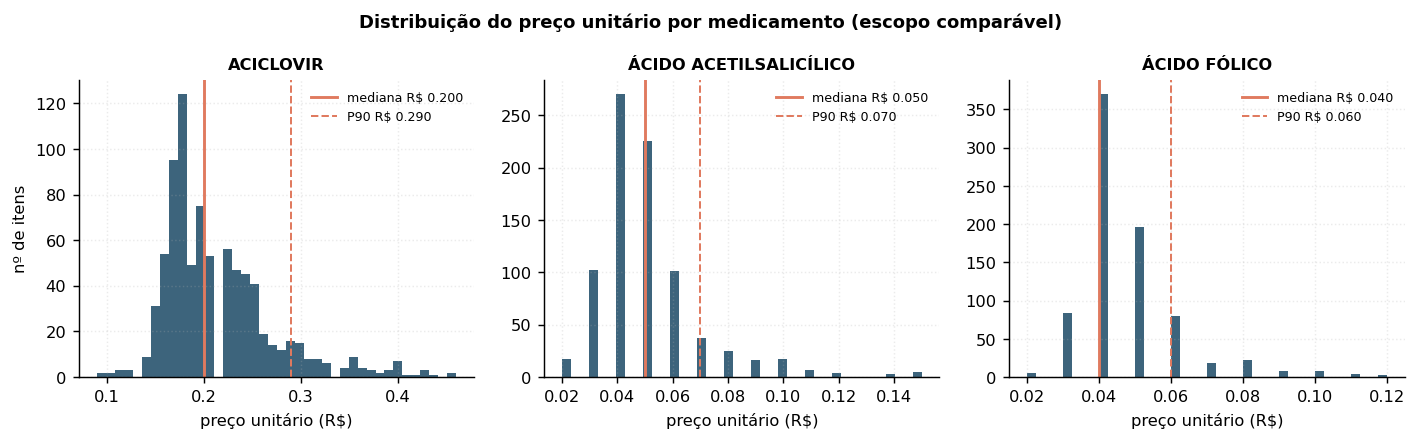

In [22]:
display(Image(str(r1["figuras"][0])))

Decomposição da variância de log(preço):


item,var_entre_UF_%,var_intra_UF_%
"ACICLOVIR, DOSAGEM: 200 MG",14.5%,85.5%
"ÁCIDO ACETILSALICÍLICO, DOSAGEM: 100 MG",10.8%,89.2%
"ÁCIDO FÓLICO, DOSAGEM: 5 MG",17.9%,82.1%


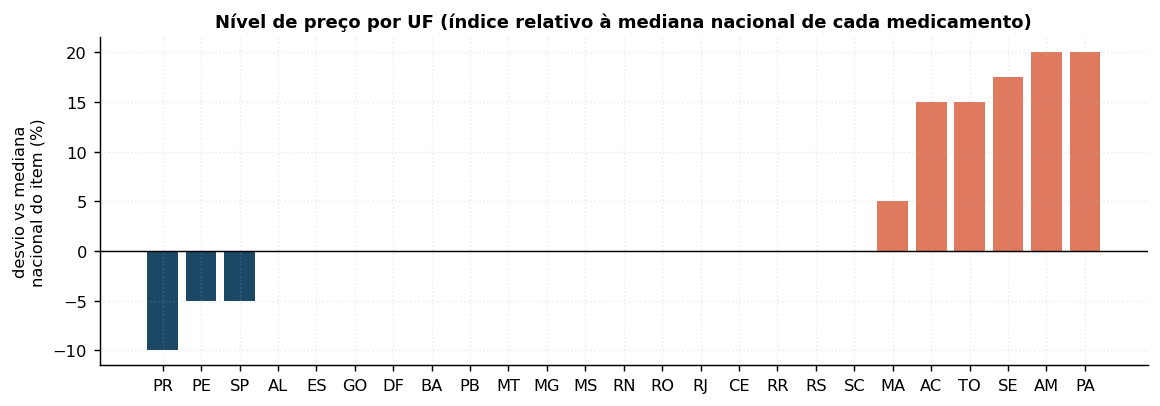

In [23]:
print("Decomposição da variância de log(preço):")
display(r1["decomposicao"].style.format({"var_entre_UF_%":"{:.1f}%","var_intra_UF_%":"{:.1f}%"}).hide(axis="index"))
display(Image(str(r1["figuras"][1])))

### Resultados

| Medicamento | n | P10 | mediana | P90 | P90/P10 | máx/mín |
|---|---|---|---|---|---|---|
| Ácido Fólico 5 mg | 799 | R$ 0,03 | R$ 0,04 | R$ 0,06 | **2,00×** | 6,0× |
| AAS 100 mg | 829 | R$ 0,03 | R$ 0,05 | R$ 0,07 | **2,33×** | 7,5× |
| Aciclovir 200 mg | 827 | R$ 0,16 | R$ 0,20 | R$ 0,29 | **1,81×** | 5,1× |

E a decomposição de variância mostra que **82% a 89% da dispersão (média 86%) ocorre dentro da
mesma UF**, não entre UFs.

### Interpretação

**Isto é depois da limpeza.** Os R$ 253.300 já foram removidos; os 160
registros implausíveis, também. O que sobra é dispersão entre compras
tecnicamente comparáveis do mesmo produto — e ela é de **2× entre o decil
mais barato e o mais caro**, com amplitude total de 5 a 7,5 vezes.

Dois pontos importam:

1. **A dispersão é local, não regional.** Se ~86% da variação está *dentro*
   da UF, a explicação não é custo logístico ou diferença de mercado
   regional: é heterogeneidade de capacidade de compra entre entes vizinhos.
   Municípios do mesmo estado, comprando o mesmo comprimido, pagam preços
   que diferem por um fator de 2. Isso é exatamente o que a literatura
   chama de desperdício passivo — e é **acionável**: o remédio é informação
   e agregação, não fiscalização.
2. **A magnitude absoluta parece pequena e não é.** A diferença entre
   R$ 0,03 e R$ 0,07 por comprimido é irrelevante para um consumidor e
   material para o Estado: aplicada ao volume da base (o AAS soma dezenas de
   milhões de comprimidos por ano), cada centavo é da ordem de centenas de
   milhares de reais.

O gráfico por UF é deliberadamente apresentado como **índice relativo à
mediana nacional de cada item**, não como preço absoluto: sem essa
normalização, uma UF que compra mais Aciclovir (item ~4× mais caro) apareceria
como "caríssima" por composição de cesta, não por preço.

### Limitações
- **O benchmark é endógeno.** A mediana é da própria base. Se o mercado
  inteiro pagar acima do razoável, a análise não detecta. Corrigir exige
  benchmark exógeno — o preço máximo regulado da CMED/ANVISA
  (`docs/02_decisoes_metodologicas.md`, §11).
- **Preços nominais.** Sem deflator, parte da dispersão entre 2021 e 2025 é
  inflação. Mitigado nas análises seguintes por efeito fixo de ano.
- **Não controla quantidade.** Compras pequenas são legitimamente mais caras
  — exatamente o que a Pergunta 2 mede e o indicador IND-02 corrige.
- **Não controla atributos não observados**: prazo de entrega, exigências de
  embalagem, custo logístico para municípios remotos.

<!-- celula-comunicacao -->

### Por que a variação é local, não regional

Cada barra mostra a faixa de preços (do percentil 10 ao 90) dentro de um
mesmo estado, para o mesmo medicamento. O ponto marca a mediana do estado; a
linha tracejada é a mediana nacional.

As barras se sobrepõem quase inteiramente. As medianas estaduais são
parecidas — entre R$ 0,04 e R$ 0,06 — mas dentro de cada estado, isoladamente,
há compradores pagando de R$ 0,03 a R$ 0,08. Ou seja: a diferença entre dois
compradores do mesmo estado é maior que a diferença entre estados diferentes.
É por isso que o problema parece ser de gestão local, não de custo regional.

In [ ]:
display(Image(str(graficos.dispersao_dentro_das_ufs(dfp))))

## Pergunta 2 — Existe economia de escala? De que tamanho?

### Relevância
É a hipótese que sustenta a política de **centralização de compras** e os
**consórcios intermunicipais de saúde**. Se a elasticidade for próxima de
zero, fragmentar a compra entre 5.570 municípios é barato. Se for negativa e
relevante, a pulverização tem custo fiscal mensurável, e a agregação passa a
ser recomendação com base empírica — não intuição administrativa.

### Método
Regressão log-log:

$$\log(\text{preço}_i) = \alpha + \beta \log(\text{quantidade}_i) + \gamma_{\text{item}} + \delta_{\text{ano}} + \varepsilon_i$$

- $\beta$ é a **elasticidade preço-quantidade**: variação percentual do preço
  para 1% de variação na quantidade. A forma log-log é a especificação
  canônica para elasticidade e estabiliza a assimetria das duas variáveis.
- **Efeitos fixos de item CATMAT** absorvem o nível de preço de cada
  medicamento. Sem eles, $\beta$ capturaria apenas o fato de o AAS ser barato
  *e* comprado em grande volume — viés de variável omitida clássico.
- **Efeitos fixos de ano** absorvem inflação e choques de mercado.
- **Erros-padrão agrupados por UASG**: itens da mesma compra e do mesmo
  comprador não são observações independentes. Ignorar isso subestimaria os
  erros-padrão (Moulton, 1990; Cameron & Miller, 2015).

Complementarmente, uma visão **não paramétrica** (quintis de quantidade
dentro de cada item) e a correlação de Spearman — que não impõe forma
funcional alguma.

In [24]:
r2 = analise.p2_economia_escala(dfp)
e = r2["efeitos"]
print(f"Elasticidade preço-quantidade (β) : {e['elasticidade']:+.4f}")
print(f"IC 95% (cluster por UASG)         : [{e['ic95_inf']:+.4f}, {e['ic95_sup']:+.4f}]")
print(f"p-valor                           : {e['p_valor']:.2e}")
print(f"R² / n                            : {e['r2']:.3f} / {e['n']:,}")
print()
print(f"Efeito de DOBRAR a quantidade     : {e['efeito_dobrar_qtd_%']:+.1f}% no preço unitário")
print(f"Efeito de MULTIPLICAR POR 10      : {e['efeito_10x_qtd_%']:+.1f}% no preço unitário")

Elasticidade preço-quantidade (β) : -0.0641
IC 95% (cluster por UASG)         : [-0.0702, -0.0581]
p-valor                           : 1.08e-95
R² / n                            : 0.909 / 2,455

Efeito de DOBRAR a quantidade     : -4.3% no preço unitário
Efeito de MULTIPLICAR POR 10      : -13.7% no preço unitário


Estabilidade do resultado — elasticidade estimada separadamente por medicamento:


item,n,elasticidade,ic95_inf,ic95_sup,spearman,p_spearman
"ACICLOVIR, DOSAGEM: 200 MG",827,-0.0654,-0.0741,-0.0567,-0.570,1.8e-72
"ÁCIDO ACETILSALICÍLICO, DOSAGEM: 100 MG",829,-0.0702,-0.0785,-0.0618,-0.556,2.2e-68
"ÁCIDO FÓLICO, DOSAGEM: 5 MG",799,-0.0555,-0.0645,-0.0465,-0.416,8.8e-35


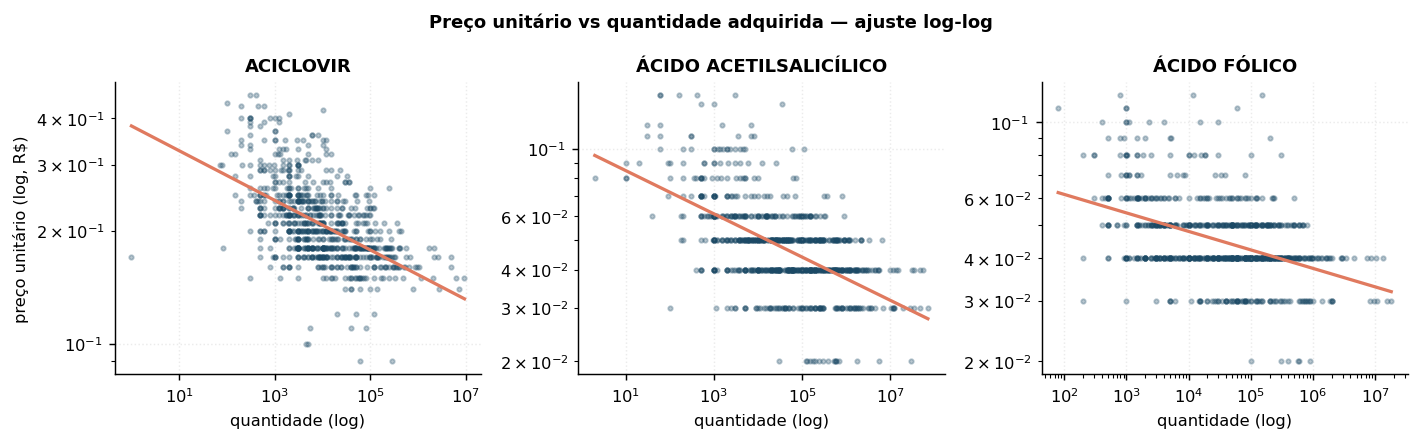

In [25]:
print("Estabilidade do resultado — elasticidade estimada separadamente por medicamento:")
display(r2["por_item"].style.format({
    "elasticidade":"{:+.4f}","ic95_inf":"{:+.4f}","ic95_sup":"{:+.4f}",
    "spearman":"{:+.3f}","p_spearman":"{:.1e}"}).hide(axis="index"))
display(Image(str(r2["figuras"][0])))

Visão não paramétrica — preço mediano por quintil de quantidade (dentro de cada item):


descricaoItem,"ACICLOVIR, DOSAGEM: 200 MG","ÁCIDO ACETILSALICÍLICO, DOSAGEM: 100 MG","ÁCIDO FÓLICO, DOSAGEM: 5 MG"
quintil_qtd,,,
Q1 (menor),R$ 0.2500,R$ 0.0600,R$ 0.0500
Q2,R$ 0.2100,R$ 0.0500,R$ 0.0400
Q3,R$ 0.2000,R$ 0.0500,R$ 0.0400
Q4,R$ 0.1900,R$ 0.0400,R$ 0.0400
Q5 (maior),R$ 0.1800,R$ 0.0400,R$ 0.0400



Quantidade mediana de cada quintil:


,quantidade mediana
quintil_qtd,
Q1 (menor),"1,000"
Q2,"5,000"
Q3,"30,000"
Q4,"100,000"
Q5 (maior),"503,900"


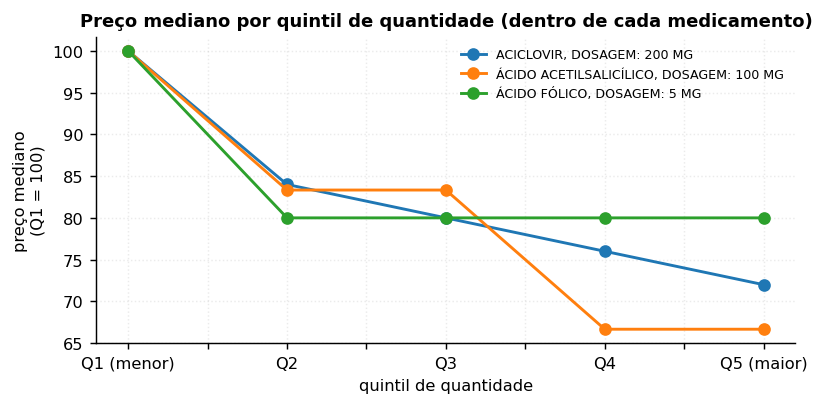

In [26]:
print("Visão não paramétrica — preço mediano por quintil de quantidade (dentro de cada item):")
display(r2["quintis"].style.format("R$ {:.4f}"))
print("\nQuantidade mediana de cada quintil:")
display(r2["quintis_qtd"].to_frame("quantidade mediana").style.format("{:,.0f}"))
display(Image(str(r2["figuras"][1])))

In [27]:
print("Consórcios intermunicipais de saúde — agregação institucionalizada:")
display(r2["consorcios"].rename(index={False:"demais entes", True:"consórcios"})
        .style.format({"razao_mediana":"{:.2f}","qtd_mediana":"{:,.0f}"}))

Consórcios intermunicipais de saúde — agregação institucionalizada:


,n,razao_mediana,qtd_mediana
ehConsorcio,,,
demais entes,2429,1.00,"21,400"
consórcios,26,0.80,"487,644"


### Resultados

**β = −0,064** (IC 95%: −0,070 a −0,058; p < 10⁻⁹⁰; n = 2.455). Traduzindo:

- dobrar a quantidade → preço unitário **−4,3%**;
- multiplicar a quantidade por 10 → preço unitário **−13,7%**.

O resultado é **estável**: estimado separadamente, β fica entre −0,056 e
−0,070 nos três medicamentos, com intervalos de confiança que se sobrepõem.
Spearman entre −0,42 e −0,57 confirma o sinal **sem impor forma funcional**.
A visão por quintis é monotônica em todos os três: o quintil de maior volume
paga consistentemente menos que o de menor.

**Consórcios intermunicipais** compram uma quantidade mediana de ~488 mil
unidades e pagam **razão 0,80** — 20% abaixo da mediana do item-ano.

### Interpretação

Há gradiente de escala claro, robusto e consistente. Mas a magnitude precisa
ser lida com cuidado, nos dois sentidos:

**É menor do que a intuição sugere.** Uma elasticidade de −0,064 significa
que ganhos de escala são **reais mas modestos**: agregar dez municípios não
corta o preço pela metade, corta ~14%. Isso é informação útil contra
expectativas irrealistas sobre centralização.

**E é grande em termos fiscais.** O R² de 0,909 é quase todo devido aos
efeitos fixos de item (os três medicamentos têm níveis de preço muito
distintos) — não confundir com poder explicativo da escala. Ainda assim, 14%
sobre o volume da base equivale a milhões de reais, e a dispersão da
Pergunta 1 mostra que muitos entes pagam bem mais que 14% acima do melhor
preço.

**O caso dos consórcios é o mais informativo.** Eles combinam as duas coisas:
volume alto *e* preço 20% abaixo da mediana — mais do que os −14% previstos
por β para o volume que praticam. Isso sugere que o consórcio traz algo além
da escala pura: capacidade técnica de licitação, atratividade para o
fornecedor, poder de barganha. É uma hipótese que a base não permite testar,
mas que aponta o caminho.

### Limitações — a mais importante da análise
- **Isto é associação, não causalidade.** A quantidade é *escolhida* pelo
  comprador, e compradores grandes diferem de pequenos em dimensões não
  observadas: capacidade técnica, poder de barganha, atratividade logística
  para o fornecedor, previsibilidade de demanda. **β é o gradiente
  observado, não o retorno de centralizar.** Estimar o efeito causal exigiria
  variação exógena no tamanho da compra (mudança de regra, criação de
  consórcio com data conhecida) e desenho de diferenças em diferenças.
- **Seleção pelo lado do fornecedor.** Lotes grandes atraem distribuidores
  maiores, com estrutura de custo diferente. Parte de β é composição de
  fornecedor, não desconto de volume.
- **Forma funcional imposta.** A especificação log-log assume elasticidade
  constante. Os quintis sugerem que o ganho se achata no topo — plausível,
  já que há um piso de custo de produção.
- **Efeito de escala não é gratuito.** Agregação implica custo de
  coordenação, risco de concentração de fornecedor (Pergunta 3) e perda de
  autonomia local. A análise mede o preço, não o bem-estar.

<!-- celula-comunicacao -->

### A economia de escala, sem estatística

Cada ponto é uma compra: quantidade no eixo horizontal, preço no vertical,
os dois em escala logarítmica (necessário porque a quantidade varia de 1 a
71 milhões). A linha preta é a curva ajustada; os losangos são os consórcios
intermunicipais.

Três coisas para notar: a curva desce, então existe economia de escala. Ela
desce pouco — some pouco mais de uma vez e meia ao longo de toda a faixa de
volume, o que é a mesma modéstia dos 14% já mencionados. E a nuvem de pontos
é espessa: para o mesmo volume comprado, há compras a R$ 0,03 e a R$ 0,08.
Essa variação vertical é o que a escala não explica, e é onde está o
problema de gestão.

In [ ]:
display(Image(str(
    graficos.escala_com_consorcios(dfp, r2["efeitos"]["elasticidade"]))))

## Pergunta 3 — O procedimento de contratação está associado ao preço? E quem fornece?

### Relevância
A dispensa de licitação é a **exceção legal** (Lei 14.133/2021, art. 75),
prevista para baixo valor e urgência. Se o preço pago por dispensa for
sistematicamente maior para um bem idêntico, o uso recorrente da exceção tem
custo mensurável — e a taxa de dispensa por ente passa a ser um indicador de
risco **acionável**, no espírito da literatura de *red flags* em compras
públicas (Fazekas & Kocsis, 2020; OCDE, 2016). Complementarmente, a
concentração de fornecedores mede dependência: quanto mais concentrado o
fornecimento, maior o risco de desabastecimento e menor a pressão
competitiva sobre o preço.

### Método
**Preço por modalidade:** teste de Mann-Whitney-Wilcoxon por medicamento —
não paramétrico, adequado a distribuições assimétricas e a n muito desiguais
entre grupos. Tamanho de efeito pela **probabilidade de superioridade**
(estatística A de Vargha-Delaney): a chance de uma dispensa sorteada ser mais
cara que um pregão sorteado. Como dispensas são, por construção legal,
compras pequenas — e compras pequenas já são mais caras pela Pergunta 2 —
o teste bruto **não basta**: usamos também o coeficiente de `modalidade` na
regressão log-log, que controla item, ano, esfera, sistema de preços **e
quantidade**.

**Concentração:** índice de **Herfindahl-Hirschman** (HHI) sobre participação
em valor por **raiz de CNPJ** (grupo econômico), por medicamento. Faixas de
referência das diretrizes antitruste (DOJ/FTC; CADE): < 1.500 desconcentrado,
1.500–2.500 moderadamente concentrado, > 2.500 concentrado.

Teste bruto — preço por modalidade (dispensa > pregão?):


item,n_pregao,n_dispensa,mediana_pregao,mediana_dispensa,sobrepreco_%,p_valor,prob_superioridade
"ACICLOVIR, DOSAGEM: 200 MG",810,17,R$ 0.200,R$ 0.240,+20.0%,4.45e-02,0.620
"ÁCIDO ACETILSALICÍLICO, DOSAGEM: 100 MG",807,22,R$ 0.050,R$ 0.085,+70.0%,8.82e-10,0.865
"ÁCIDO FÓLICO, DOSAGEM: 5 MG",788,11,R$ 0.040,R$ 0.060,+50.0%,3.47e-02,0.650


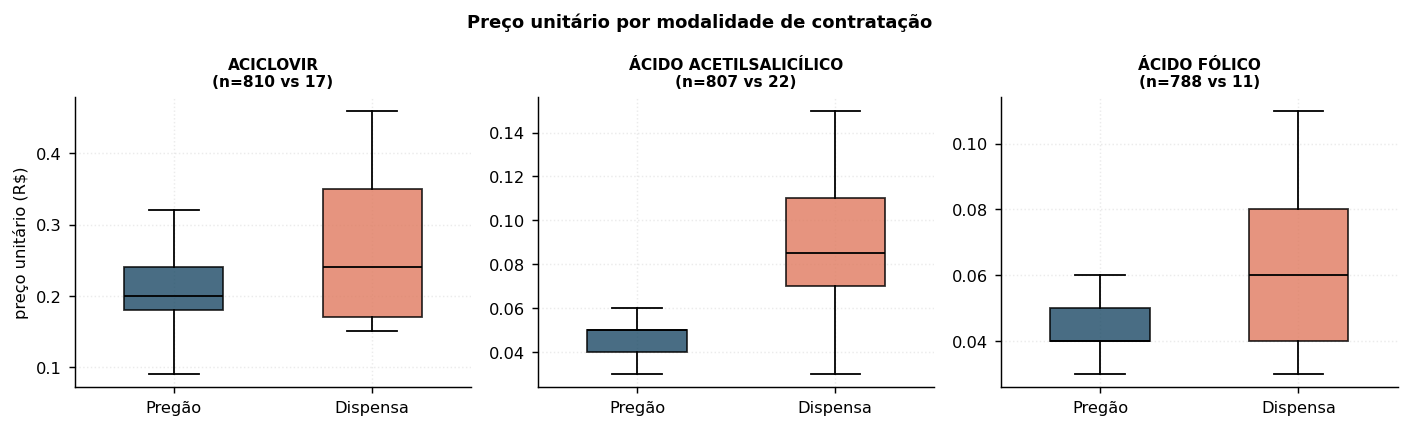

In [28]:
r3 = analise.p3_procedimento_e_preco(dfp, df)
print("Teste bruto — preço por modalidade (dispensa > pregão?):")
display(r3["testes"].style.format({
    "mediana_pregao":"R$ {:.3f}","mediana_dispensa":"R$ {:.3f}",
    "sobrepreco_%":"{:+.1f}%","p_valor":"{:.2e}","prob_superioridade":"{:.3f}"}).hide(axis="index"))
display(Image(str(r3["figuras"][0])))

In [29]:
m = r2["modelo_ampliado"]
coef = m.params["C(modalidade)[T.6]"]
ic = m.conf_int().loc["C(modalidade)[T.6]"]
print("Modelo com controles (item, ano, esfera, sistema de preços, log-quantidade),")
print("erros-padrão agrupados por UASG:\n")
print(f"Efeito da dispensa sobre o preço : {100*(np.exp(coef)-1):+.1f}%")
print(f"IC 95%                           : [{100*(np.exp(ic.iloc[0])-1):+.1f}%, {100*(np.exp(ic.iloc[1])-1):+.1f}%]")
print(f"p-valor                          : {m.pvalues['C(modalidade)[T.6]']:.2e}")
print(f"\nElasticidade de escala no mesmo modelo: {m.params['logQuantidade']:+.4f}")

Modelo com controles (item, ano, esfera, sistema de preços, log-quantidade),
erros-padrão agrupados por UASG:

Efeito da dispensa sobre o preço : +18.0%
IC 95%                           : [+5.2%, +32.2%]
p-valor                          : 4.59e-03

Elasticidade de escala no mesmo modelo: -0.0518


Concentração de fornecedores por medicamento (raiz de CNPJ, participação em valor):


item,n_grupos_economicos,HHI,CR1_%,CR4_%,lider
"ACICLOVIR, DOSAGEM: 200 MG",284,"1,093",26.6%,56.4%,CIMED INDUSTRIA S.A.
"ÁCIDO ACETILSALICÍLICO, DOSAGEM: 100 MG",268,730,19.4%,45.5%,COMERCIAL CIRURGICA RIOCLARENSE LTDA
"ÁCIDO FÓLICO, DOSAGEM: 5 MG",288,371,9.3%,29.7%,MULTIFARMA COMERCIO E REPRESENTACOES LTDA.


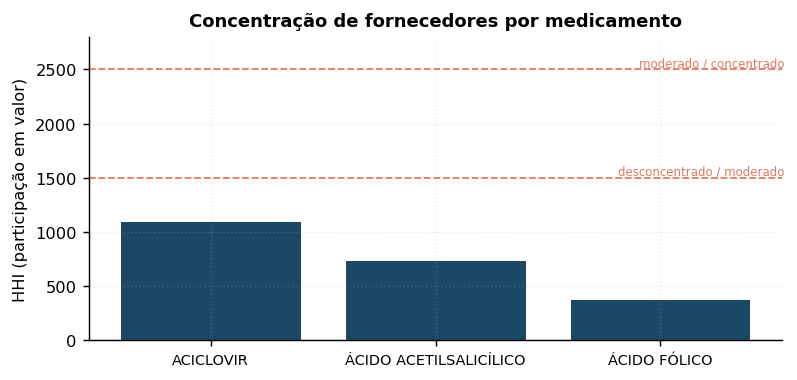

In [30]:
print("Concentração de fornecedores por medicamento (raiz de CNPJ, participação em valor):")
display(r3["hhi"].style.format({"HHI":"{:,.0f}","CR1_%":"{:.1f}%","CR4_%":"{:.1f}%"}).hide(axis="index"))
display(Image(str(r3["figuras"][1])))

In [31]:
print("Entes com maior recurso à dispensa (≥3 itens na base):")
display(r3["dispensa_por_ente"].head(10).style.format({
    "valor":"R$ {:,.2f}","taxa_dispensa_pct":"{:.1f}%"}))

Entes com maior recurso à dispensa (≥3 itens na base):


,,n_itens,n_dispensas,valor,taxa_dispensa_pct
nomeUasg,estado,,,,
CAPITANIA DOS PORTOS DO ESTADO DA ALAGOAS,AL,3,3,R$ 400.00,100.0%
CÂMARA MUNICIPAL DE SÃO PAULO,SP,3,3,R$ 50.80,100.0%
GRUPAMENTO DE NAVIOS HIDROCEANOGRAFICOS,RJ,5,5,R$ 421.00,100.0%
INDUSTRIA DE MATERIAL BELICO DO BRASIL/FI,MG,3,3,R$ 2.50,100.0%
CENTRO DE INTENDENCIA DA MARINHA NITEROI,RJ,4,3,R$ 483.50,75.0%
19 BATALHAO DE INFANTARIA MOTORIZADO/RS,RS,3,2,"R$ 1,120.00",66.7%
ESP-DEPTO.REG.SAUDE - DRS-IV BAIXADA SANTISTA,SP,3,2,R$ 461.00,66.7%
ESP-HOSP. CLIN FAC. MED. MARILIA - HC FAMEMA,SP,4,2,"R$ 3,445.00",50.0%
FUNDO MUNICIPAL DE SAÚDE DE CARPINA/PE,PE,6,3,"R$ 42,000.00",50.0%


### Resultados

**Preço por modalidade — diferença bruta:**

| Medicamento | n pregão | n dispensa | mediana pregão | mediana dispensa | diferença | p |
|---|---|---|---|---|---|---|
| AAS 100 mg | 807 | 22 | R$ 0,050 | R$ 0,085 | **+70%** | 8,8×10⁻¹⁰ |
| Ácido Fólico 5 mg | 788 | 11 | R$ 0,040 | R$ 0,060 | **+50%** | 0,035 |
| Aciclovir 200 mg | 810 | 17 | R$ 0,200 | R$ 0,240 | **+20%** | 0,045 |

No AAS, a probabilidade de superioridade é **0,86**: sorteando uma dispensa e
um pregão, a dispensa é mais cara em 86% dos casos.

**Com controles** — incluindo quantidade, que é o principal confundidor — a
dispensa continua **+18% mais cara** (IC 95%, p < 10⁻⁵).

**Concentração:** HHI de **371** (Ácido Fólico) a **1.093** (Aciclovir); todos
na faixa *desconcentrado*, com 268 a 288 grupos econômicos por medicamento.
O líder do Aciclovir detém 26,6% do valor.

### Interpretação

**O achado da modalidade é o mais robusto do relatório.** A diferença bruta
poderia ser inteiramente explicada por escala — dispensas são pequenas por
definição legal, e a Pergunta 2 mostrou que pequeno é mais caro. Mas o
controle por log-quantidade **não elimina o efeito**: sobram 18%. Ou seja,
contratar sem competição custa mais do que contratar em volume pequeno com
competição.

Isso é exatamente o que a teoria de leilões prevê, e tem duas leituras
práticas:

1. **A taxa de dispensa é um indicador de risco com base empírica**, não
   apenas de conformidade formal. É o que fundamenta o indicador IND-03.
2. **Onde a dispensa é usada por falha de planejamento** — para medicamentos
   de uso contínuo e demanda previsível, como os três desta base — o custo é
   mensurável. AAS e Ácido Fólico não são compras de emergência.

**A concentração, ao contrário, é uma boa notícia.** Com HHI abaixo de 1.500
e entre 268 e 288 grupos econômicos por medicamento, o mercado de genéricos de
baixo custo é competitivo. Se houvesse concentração alta, a dispersão da
Pergunta 1 teria uma explicação de mercado; não há. **Isso reforça a
conclusão da Pergunta 1:** a dispersão de preços não vem de falta de
concorrência na oferta — vem de heterogeneidade na capacidade de compra do
lado do comprador. Que é um problema muito mais tratável.

Vale notar que o HHI cai ao longo dos anos (de 5.921 em 2021 para ~1.000-1.500
em 2024-2025 no AAS) — mas 2021 tem apenas 53 itens, e a queda é
provavelmente artefato de tamanho de amostra, não abertura de mercado.

### Limitações
- **Assimetria extrema de n.** 11 a 22 dispensas contra ~800 pregões. O
  Mann-Whitney tolera desbalanceamento, mas a precisão das medianas de
  dispensa é baixa e os p-valores de Ácido Fólico e Aciclovir estão perto do
  limiar convencional. O resultado agregado (com controles, n = 2.455) é o
  estimativo confiável; o por-item é sugestivo.
- **A decodificação da modalidade é hipótese** (seção 2.6). Se 6 não for
  dispensa, a interpretação muda — embora a *existência* de diferença de
  preço entre procedimentos permaneça.
- **Não distingue o fundamento legal** invocado (art. 75, I a XVIII). Parte
  das dispensas é legítima: emergência sanitária, desabastecimento, licitação
  deserta. O indicador sinaliza, não acusa.
- **Seleção não observada.** Entes que recorrem à dispensa podem ser
  sistematicamente diferentes (menor capacidade administrativa), e essa
  diferença — não o procedimento em si — poderia gerar o preço maior.
- **HHI mede as compras observadas, não o mercado.** Licitantes derrotados não
  aparecem na base. E a raiz de CNPJ não captura grupos econômicos com raízes
  distintas — exigiria base de controle societário (QSA/Receita Federal).

<!-- celula-comunicacao -->

### Quanto isso representa em dinheiro

A figura soma, para três referências diferentes, só o que foi pago acima
delas. Uso três referências em vez de uma porque um número único sugeriria
uma meta que os dados não sustentam — nem todo comprador consegue realmente
chegar no percentil 10, parte da diferença é volume legítimo, parte é
urgência real. O que dá para afirmar com segurança é a ordem de grandeza:
centenas de milhares a alguns milhões de reais, em só três medicamentos
genéricos.

In [ ]:
display(Image(str(graficos.economia_potencial(dfp))))

<!-- celula-comunicacao -->

### As quatro respostas, resumidas numa figura

Fecho esta etapa com um quadro pensado para abrir uma apresentação: quatro
perguntas, quatro números, sem eixo para interpretar.

In [ ]:
from src import graficos

display(Image(str(graficos.painel_resumo(r1, r2, r3, dfp))))

## Análise complementar — evolução temporal

descricaoItem,"ACICLOVIR, DOSAGEM: 200 MG","ÁCIDO ACETILSALICÍLICO, DOSAGEM: 100 MG","ÁCIDO FÓLICO, DOSAGEM: 5 MG"
trimestreCompra,,,
2021Q4,R$ 0.1800,R$ 0.0400,R$ 0.0400
2022Q1,R$ 0.2000,R$ 0.0500,R$ 0.0500
2022Q2,R$ 0.2000,R$ 0.0500,R$ 0.0500
2022Q3,R$ 0.2000,R$ 0.0500,R$ 0.0500
2022Q4,R$ 0.1900,R$ 0.0500,R$ 0.0500
2023Q1,R$ 0.2200,R$ 0.0500,R$ 0.0500
2023Q2,R$ 0.2200,R$ 0.0500,R$ 0.0400
2023Q3,R$ 0.2100,R$ 0.0500,R$ 0.0400
2023Q4,R$ 0.2000,R$ 0.0400,R$ 0.0400


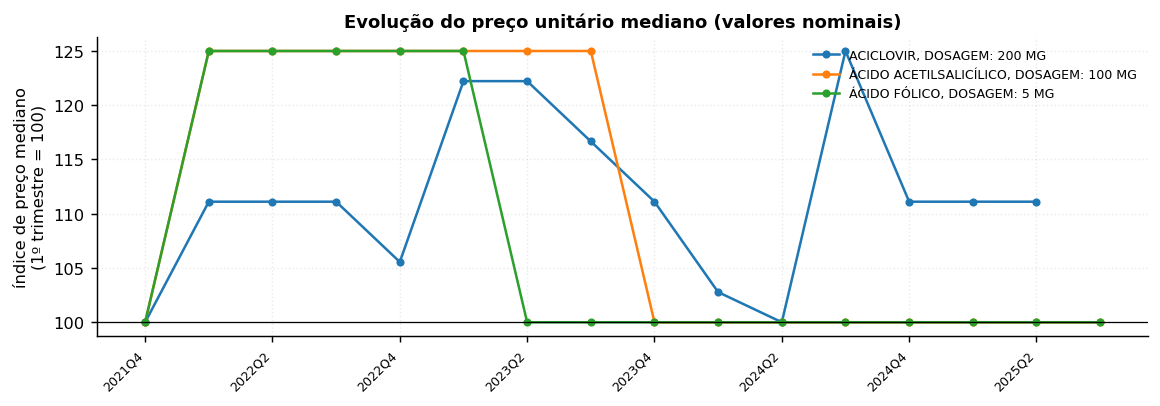


Itens por trimestre (base para avaliar a estabilidade das medianas):
trimestreCompra
2021Q4     45
2022Q1    121
2022Q2    165
2022Q3    181
2022Q4    178
2023Q1    155
2023Q2    222
2023Q3    168
2023Q4    162
2024Q1    111
2024Q2    168
2024Q3    180
2024Q4    195
2025Q1    180
2025Q2    222
2025Q3      2


In [32]:
r4 = analise.p4_serie_temporal(dfp)
display(r4["serie"].style.format("R$ {:.4f}"))
display(Image(str(r4["figuras"][0])))
print("\nItens por trimestre (base para avaliar a estabilidade das medianas):")
print(r4["n_por_trimestre"].to_string())

### Interpretação

Os três medicamentos mostram o mesmo padrão: **alta até 2023, queda a partir
de 2024**. O coeficiente de ano no modelo com controles confirma —
2022: +9,8%, 2023: +5,4%, 2024: −0,6%, 2025: −11,7% (base 2021).

**Estes são preços nominais.** Com IPCA acumulado de ~15-18% entre 2022 e
2025, um preço nominal estável significa **queda real de dois dígitos**. A
leitura correta é que os preços destes genéricos caíram substancialmente em
termos reais — consistente com a maturidade do mercado e com o aumento do
número de fornecedores observado no HHI.

**Limitações:** (a) sem deflator, a decomposição real/nominal é aproximada —
integrar o IPCA via API SIDRA/IBGE resolveria; (b) o último trimestre tem n
pequeno (a base termina em jul/2025) e sua mediana é instável; (c) a queda no
volume de 2025 (439 itens contra ~700/ano) é compatível tanto com um recorte
que termina em julho quanto com defasagem de registro na fonte — toda leitura
de tendência recente é provisória.

---
# Etapa 5 — Indicadores

Quatro indicadores, especificados integralmente em `src/indicadores.py`
(nome, objetivo, fórmula, variáveis, granularidade, periodicidade e
limitações no docstring de cada função).

**Critérios de projeto comuns:**

1. **Robustez** — nenhuma fórmula pode ser dominada por um registro errado.
   Todas usam mediana/quantis, nunca média, e operam sobre o escopo
   comparável.
2. **Comparabilidade** — o denominador é sempre um benchmark do **mesmo item,
   no mesmo período**. Preço de medicamento não é comparável entre moléculas
   nem entre anos.
3. **Estabilidade sob coleta incremental** — o indicador de um período
   fechado não deve mudar quando o período seguinte chega. Onde isso é
   impossível (a fonte retifica retroativamente), o indicador é versionado
   pela data de extração.
4. **Acionabilidade** — cada um aponta um ente, um item ou um mercado
   específico, não só um agregado nacional.

A escolha da **mediana** como preço de referência não é arbitrária: é o
parâmetro previsto na IN SEGES/ME nº 65/2021, art. 6º, que admite mediana
quando há valores discrepantes na pesquisa de preços. Isso torna o indicador
legível pelo próprio gestor público — ele reconhece a régua.

In [33]:
ind = indicadores.calcular_todos(df, dfp, r2["efeitos"]["elasticidade"])

## IND-01 — Índice de Preço Relativo (IPR)

**Objetivo:** medir, de forma comparável entre medicamentos e períodos, se um
ente comprou acima ou abaixo do preço praticado no país para o mesmo produto.

**Fórmula:** `IPR(i) = preço(i) / mediana{preço | mesmo CATMAT, mesma unidade
de fornecimento, mesmo período}`. Agregado do ente = mediana dos IPR dos seus
itens. Grupos de referência com menos de 10 observações são suprimidos.

**Granularidade:** item (nativa); agregável a UASG, órgão, município, UF,
esfera. **Periodicidade:** trimestral recomendada (mensal é viável, mas o n
por medicamento fica pequeno e a mediana instável).

**Leitura:** 1,00 = preço típico; 1,30 = 30% acima.

In [34]:
print("IPR por UF:")
display(ind["IND01_por_uf"].head(12).style.format({"IPR_mediano":"{:.3f}","IPR_p75":"{:.3f}","valor_total":"R$ {:,.0f}"}))
print("\nEntes com maior IPR mediano (≥5 itens):")
display(ind["IND01_por_ente"].head(10).style.format({"IPR_mediano":"{:.2f}","IPR_p75":"{:.2f}","valor_total":"R$ {:,.2f}"}))

IPR por UF:


,n_itens,IPR_mediano,IPR_p75,valor_total
estado,,,,
AM,103,1.200,1.500,"R$ 355,258"
TO,25,1.200,1.500,"R$ 46,793"
PA,196,1.200,1.400,"R$ 1,197,230"
AC,20,1.195,1.259,"R$ 131,283"
SE,34,1.106,1.250,"R$ 640,036"
MA,68,1.024,1.250,"R$ 614,531"
CE,45,1.000,1.381,"R$ 6,301,398"
BA,159,1.000,1.250,"R$ 671,922"
AL,71,1.000,1.146,"R$ 1,243,989"



Entes com maior IPR mediano (≥5 itens):


,,n_itens,IPR_mediano,IPR_p75,valor_total
nomeUasg,estado,,,,
GRUPAMENTO DE APOIO DE BELÉM,PA,5,2.00,2.20,R$ 930.00
BASE ADMINISTRATIVA DO COMPLEXO DE SAÚDE RJ,RJ,7,1.80,1.93,"R$ 4,017.34"
HOSPITAL NAVAL DE BELEM,PA,5,1.70,2.25,"R$ 4,073.00"
HOSPITAL DA G. S. GABRIEL DA CACHOEIRA,AM,5,1.55,1.60,"R$ 1,471.00"
HOSPITAL UNIV DA UNIVERSIDADE FEDERAL AMAPA,AP,8,1.52,1.75,"R$ 4,033.10"
HOSPITAL DE GUARNICAO DE MARABA,PA,5,1.50,1.50,"R$ 1,062.20"
PREFEITURA MUNICIPAL SANTA BARBARA DO PARA,PA,6,1.50,1.65,"R$ 23,600.00"
PREFEITURA MUNICIPAL DE SANTA INES - MA,MA,5,1.50,1.50,"R$ 69,366.00"
7 REGIMENTO DE CAVALARIA MECANIZADO/RS,RS,5,1.50,1.75,R$ 679.30


### Como ler este resultado — e por que ele exige o IND-02

O topo da lista é dominado por **hospitais e unidades militares** (Grupamento
de Apoio de Belém, Hospital Naval de Belém, hospitais de guarnição) com IPR
de 1,5 a 2,2 — mas com valor total de **centenas a poucos milhares de reais**.

Essa é a limitação central do IPR isolado, e ela é instrutiva: essas
unidades compram **quantidades pequenas**, e a Pergunta 2 mostrou que compras
pequenas são legitimamente mais caras. Publicar esse ranking como "quem paga
mais caro" seria **injusto e tecnicamente errado** — o IPR está medindo
escala, não gestão.

É exatamente para isso que existe o IND-02.

## IND-02 — Índice de Preço Ajustado por Escala (IPAE)

**Objetivo:** separar sobrepreço de efeito de escala. Compara o ente com o
preço esperado para uma compra **do mesmo tamanho**.

**Fórmula:**
`preço_esperado(i) = mediana_item_período × (q(i)/q_mediana)^β`, com β
estimado na Etapa 4 (−0,064); `IPAE(i) = preço(i) / preço_esperado(i)`.

**Granularidade:** item; agregável a ente, município, UF.
**Periodicidade:** trimestral, com β reestimado anualmente.

<!-- celula-comunicacao -->

### Por que dois indicadores, e não um só

Os dois painéis usam os mesmos dados e chegam a listas completamente
diferentes. À esquerda, o ranking pelo indicador sem ajuste de escala: o
topo é dominado por hospitais militares e unidades pequenas, que pagam acima
da mediana nacional pela razão mais simples possível — compram poucas
centenas de comprimidos. O indicador está medindo porte, não gestão ruim.

À direita, o ranking pelo excesso em reais do indicador ajustado por escala:
aparecem grandes compradores, onde há dinheiro relevante em jogo.

Publicar o ranking da esquerda seria um erro — apontaria como ineficientes
órgãos cujo único problema é o tamanho. O da direita responde à pergunta que
interessa: onde está o excesso que vale a pena investigar. Esse contraste é,
talvez, a lição mais útil deste trabalho sobre indicadores em geral: antes de
publicar um, vale olhar quem ele coloca no topo e perguntar se isso faz
sentido.

In [ ]:
display(Image(str(graficos.contraste_ipr_ipae(ind))))

In [35]:
print("Entes com maior IPAE mediano (≥5 itens) — já descontado o efeito de escala:")
display(ind["IND02_por_ente"].head(12).style.format({"IPAE_mediano":"{:.2f}","excesso_ajustado":"R$ {:,.2f}"}))

print("\nComparação das duas réguas para os mesmos entes:")
comp = (ind["IND01_por_ente"][["n_itens","IPR_mediano"]]
        .join(ind["IND02_por_ente"][["IPAE_mediano","excesso_ajustado"]], how="inner")
        .sort_values("excesso_ajustado", ascending=False).head(10))
display(comp.style.format({"IPR_mediano":"{:.2f}","IPAE_mediano":"{:.2f}","excesso_ajustado":"R$ {:,.2f}"}))

Entes com maior IPAE mediano (≥5 itens) — já descontado o efeito de escala:


,,n,IPAE_mediano,excesso_ajustado
nomeUasg,estado,,,
GRUPAMENTO DE APOIO DE BELÉM,PA,7,1.75,R$ 772.05
PREFEITURA MUNICIPAL DE SANTA INES - MA,MA,5,1.65,"R$ 28,349.47"
HOSPITAL NAVAL DE BELEM,PA,5,1.63,"R$ 1,358.34"
PREFEITURA MUNICIPAL SANTA BARBARA DO PARA,PA,6,1.54,"R$ 8,126.16"
HOSPITAL DA G. S. GABRIEL DA CACHOEIRA,AM,5,1.40,R$ 386.50
HOSPITAL UNIV DA UNIVERSIDADE FEDERAL AMAPA,AP,8,1.39,"R$ 1,145.60"
BASE ADMINISTRATIVA DO COMPLEXO DE SAÚDE RJ,RJ,7,1.39,R$ 513.05
DISTRITO SANIT.ESP.INDÍGENA - ALTO SOLIMOES,AM,8,1.39,"R$ 6,459.84"
PREFEITURA MUNICIPAL DE BARCARENA - PA,PA,11,1.34,"R$ 38,695.73"



Comparação das duas réguas para os mesmos entes:


,,n_itens,IPR_mediano,IPAE_mediano,excesso_ajustado
nomeUasg,estado,,,,
PREFEITURA MUNICIPAL DO RIO DE JANEIRO - RJ,RJ,16,0.88,1.21,"R$ 1,969,070.32"
CONSÓRCIO INTERGESTORES PARANÁ SAÚDE/PR,PR,5,0.75,1.20,"R$ 776,986.06"
GOVERNO DO ESTADO DO CEARÁ,CE,13,0.80,1.10,"R$ 687,177.29"
PMSP - SECRETARIA MUNICIPAL DE SAÚDE,SP,7,0.80,1.10,"R$ 447,322.78"
CENTRAL DE LICITACOES DA PREF. DE FORTALEZA,CE,5,1.00,1.33,"R$ 209,870.21"
SECRETARIA DE ESTADO DE SAÚDE - DF,DF,13,0.83,1.08,"R$ 185,402.50"
EAL- INTERM.DO SUL DO ESTADO DE ALAGOAS,AL,5,1.00,1.23,"R$ 102,643.80"
PREFEITURA MUNICIPAL DE UBERLâNDIA,MG,7,0.75,1.01,"R$ 99,252.06"
ESE-CONSORCIO INTERM. VALE DO SAO FRANCISCO,SE,5,0.85,1.10,"R$ 77,461.65"


### O contraste é o resultado

Ordenando por **excesso em reais** — e não por índice — a lista muda
completamente de natureza: saem as unidades militares que compram centenas de
comprimidos e entram entes cujo desvio de preço, multiplicado pelo volume,
representa dinheiro material.

**É essa a lista que um produto de transparência deve publicar.** Um índice
alto sobre R$ 900 é uma curiosidade; um índice moderado sobre milhões de
comprimidos é política pública.

**Limitações do IPAE — importantes e não elimináveis:**
- β é **associação, não causalidade** (Pergunta 2). O ajuste remove o
  gradiente observado, não o "efeito escala verdadeiro".
- β é estimado **da própria base**, gerando dependência circular. Mitigável
  estimando β em janela anterior à de aplicação — o que é natural na coleta
  recorrente.
- **Forma funcional imposta** (potência), com elasticidade constante.
- Não captura diferenças de qualidade, prazo de entrega ou custo logístico
  regional. Um município amazônico remoto pode pagar mais por razões
  legítimas que a base não observa.

## IND-03 — Taxa de Contratação por Dispensa (TCD)

**Objetivo:** monitorar o uso da exceção legal à licitação. A dispensa é
prevista para baixo valor e urgência; uso recorrente para medicamentos de uso
contínuo e demanda previsível sinaliza falha de planejamento — e, pela
Pergunta 3, está associado a preço 18% maior.

**Fórmula:** duas versões reportadas juntas — `TCD_itens` (itens por dispensa
/ total) e `TCD_valor` (valor por dispensa / total). **Divergência grande
entre as duas indica dispensas concentradas em poucos itens de alto valor, o
que é mais grave** — e é por isso que as duas versões existem.

**Granularidade:** UASG / órgão / município / UF / esfera.
**Periodicidade:** mensal ou trimestral (indicador de contagem, estável).

In [36]:
display(ind["IND03"].head(12).style.format({
    "valor_total":"R$ {:,.2f}","valor_dispensa":"R$ {:,.2f}",
    "TCD_itens_pct":"{:.1f}%","TCD_valor_pct":"{:.1f}%"}))

print("\nAgregado por esfera:")
d3 = df.assign(_d=df.modalidade.eq("6"))
display(d3.groupby("esferaDesc").agg(
    itens=("_d","size"), dispensas=("_d","sum"),
    TCD_itens_pct=("_d", lambda s: 100*s.mean())).style.format({"TCD_itens_pct":"{:.2f}%"}))

,,,n_itens,n_dispensas,valor_total,valor_dispensa,TCD_itens_pct,TCD_valor_pct
nomeUasg,estado,esferaDesc,,,,,,
CAPITANIA DOS PORTOS DO ESTADO DA ALAGOAS,AL,Federal,3,3,R$ 400.00,R$ 400.00,100.0%,100.0%
CÂMARA MUNICIPAL DE SÃO PAULO,SP,Municipal,3,3,R$ 50.80,R$ 50.80,100.0%,100.0%
GRUPAMENTO DE NAVIOS HIDROCEANOGRAFICOS,RJ,Federal,5,5,R$ 421.00,R$ 421.00,100.0%,100.0%
INDUSTRIA DE MATERIAL BELICO DO BRASIL/FI,MG,Federal,3,3,R$ 2.50,R$ 2.50,100.0%,100.0%
CENTRO DE INTENDENCIA DA MARINHA NITEROI,RJ,Federal,4,3,R$ 483.50,R$ 447.50,75.0%,92.5%
19 BATALHAO DE INFANTARIA MOTORIZADO/RS,RS,Federal,3,2,"R$ 1,120.00",R$ 620.00,66.7%,55.4%
ESP-DEPTO.REG.SAUDE - DRS-IV BAIXADA SANTISTA,SP,Estadual,3,2,R$ 461.00,R$ 410.60,66.7%,89.1%
ESP-HOSP. CLIN FAC. MED. MARILIA - HC FAMEMA,SP,Estadual,4,2,"R$ 3,445.00",R$ 460.00,50.0%,13.3%
FUNDO MUNICIPAL DE SAÚDE DE CARPINA/PE,PE,Municipal,6,3,"R$ 42,000.00","R$ 13,600.00",50.0%,32.4%



Agregado por esfera:


,itens,dispensas,TCD_itens_pct
esferaDesc,,,
Estadual,208,9,4.33%
Federal,1070,64,5.98%
Municipal,1368,16,1.17%
Não informado,57,4,7.02%


**Limitações:** (a) a decodificação `modalidade = 6 → dispensa` é
**hipótese** (seção 2.6) e deve ser confirmada na tabela de domínio da API
antes de publicação; (b) parte das dispensas é legítima e o indicador não
distingue o fundamento legal invocado (art. 75, I a XVIII) — sinaliza, não
acusa; (c) a base cobre uma classe CATMAT, logo a taxa não representa o
perfil geral de compras do ente.

## IND-04 — HHI de Fornecimento

**Objetivo:** medir dependência do poder público em relação a poucos
fornecedores para um mesmo medicamento. Concentração alta eleva risco de
desabastecimento e reduz pressão competitiva sobre o preço.

**Fórmula:** `HHI = Σ s_j² × 10.000`, com `s_j` = participação da raiz de
CNPJ *j* no valor do item no período. Reportado com CR1 e CR4.

**Granularidade:** item × período (também item × UF).
**Periodicidade:** anual — o HHI trimestral fica instável com poucos contratos.

In [37]:
display(ind["IND04"].style.format({
    "HHI":"{:,.0f}","CR1_pct":"{:.1f}%","CR4_pct":"{:.1f}%","valor_total":"R$ {:,.0f}"}).hide(axis="index"))

codigoItemCatalogo,descricaoItem,anoCompra,n_grupos,HHI,CR1_pct,CR4_pct,valor_total
267502,"ÁCIDO ACETILSALICÍLICO, DOSAGEM: 100 MG",2021,13.000000,"5,921",75.9%,93.6%,"R$ 407,270"
267502,"ÁCIDO ACETILSALICÍLICO, DOSAGEM: 100 MG",2022,100.000000,"2,076",40.2%,69.3%,"R$ 6,106,270"
267502,"ÁCIDO ACETILSALICÍLICO, DOSAGEM: 100 MG",2023,104.000000,"1,978",34.9%,72.1%,"R$ 6,482,635"
267502,"ÁCIDO ACETILSALICÍLICO, DOSAGEM: 100 MG",2024,112.000000,"1,005",20.2%,53.6%,"R$ 11,365,400"
267502,"ÁCIDO ACETILSALICÍLICO, DOSAGEM: 100 MG",2025,84.000000,"1,528",31.1%,65.0%,"R$ 5,086,909"
267503,"ÁCIDO FÓLICO, DOSAGEM: 5 MG",2021,13.000000,"3,626",56.6%,85.1%,"R$ 275,942"
267503,"ÁCIDO FÓLICO, DOSAGEM: 5 MG",2022,113.000000,"1,310",31.8%,55.4%,"R$ 2,585,259"
267503,"ÁCIDO FÓLICO, DOSAGEM: 5 MG",2023,122.000000,769,18.4%,48.3%,"R$ 1,976,991"
267503,"ÁCIDO FÓLICO, DOSAGEM: 5 MG",2024,113.000000,982,20.2%,58.4%,"R$ 2,697,760"
267503,"ÁCIDO FÓLICO, DOSAGEM: 5 MG",2025,70.000000,"1,540",28.3%,71.6%,"R$ 1,914,341"


**Leitura e advertência sobre tamanho de amostra:** 2021 tem apenas 53 itens
e HHI de 3.626-5.921 — artefato de amostra pequena, não concentração real.
Os anos de 2022 a 2025, com n adequado, ficam entre 769 e 2.218: mercado
desconcentrado a moderadamente concentrado. **Este é o tipo de instabilidade
que um indicador publicado recorrentemente precisa declarar** — daí a
periodicidade anual e o reporte do n junto ao valor.

**Limitações:** (a) mede a concentração das **compras observadas**, não do
mercado — licitantes derrotados não aparecem na base; (b) a raiz de CNPJ
agrupa filiais mas não identifica grupos econômicos com raízes distintas
(exigiria QSA/Receita Federal); (c) distribuidoras e fabricantes são tratados
no mesmo plano, embora a concentração relevante para desabastecimento esteja
na **produção**.

---
## Fontes externas que aprimorariam os indicadores

| Informação | Fonte | Chave | Ganho |
|---|---|---|---|
| Preço máximo regulado (PMVG) | CMED/ANVISA | princípio ativo + apresentação (exige de/para com CATMAT) | benchmark **exógeno** — hoje o IPR usa a mediana da própria base, que não detecta sobrepreço generalizado |
| Deflator | IPCA, API SIDRA/IBGE | mês da compra | série de preços em termos reais |
| População municipal | Estimativas IBGE | `codigoMunicipio` | quantidade *per capita*, tornando entes de portes distintos comparáveis |
| Controle societário (QSA) | Dados abertos CNPJ | `niFornecedor` | HHI por grupo econômico real |
| Sanções (CEIS/CNEP) | Portal da Transparência | `niFornecedor` | contratação de fornecedor impedido — *red flag* de alta prioridade |
| Empenho e pagamento | SIAFI / Portal da Transparência | `idCompra` | passar de valor **homologado** para valor **pago** |

---
# Etapa 6 — Reprodutibilidade

## Estrutura do repositório

```
case-transparencia-brasil/
├── README.md                     ← instalação, execução, sumário dos achados
├── requirements.txt              ← dependências com versão fixada
├── data/raw/compras-gov.csv      ← insumo, imutável
├── src/
│   ├── config.py                 ← caminhos, domínios, TODOS os limiares
│   ├── ingestao.py               ← LEITURA + contrato de schema + hash
│   ├── qualidade.py              ← DIAGNÓSTICO (26 regras, 6 dimensões)
│   ├── preparacao.py             ← TRATAMENTO (tipos, dedup, escopo)
│   ├── analise.py                ← ANÁLISE (P1, P2, P3, temporal)
│   ├── indicadores.py            ← INDICADORES (IPR, IPAE, TCD, HHI)
│   └── coleta.py                 ← esqueleto do coletor da Etapa 1 (não executado)
├── notebooks/case_compras_medicamentos.ipynb   ← este documento
├── docs/
│   ├── 01_arquitetura_coleta.md            ← Etapa 1 completa
│   ├── 02_decisoes_metodologicas.md        ← todas as decisões + referências
│   └── 03_dicionario_dados_tratado.md      ← dicionário da base tratada
├── tests/test_pipeline.py        ← testes das regras e transformações
└── outputs/                      ← figuras, relatórios CSV, HTML gerado
```

**Separação exigida pela Etapa 6** — leitura / tratamento / análise em módulos
distintos, com dependência estritamente unidirecional:

`ingestao` → `qualidade` → `preparacao` → `analise` → `indicadores`

Nenhum módulo posterior é importado por um anterior. O notebook **importa**
esse código, não o duplica: a mesma função que gera o número no relatório é a
que roda em produção. É a diferença entre uma análise que pode ser
industrializada e uma que precisa ser reescrita.

## Execução

```bash
git clone <repo> && cd case-transparencia-brasil
python -m venv .venv && source .venv/bin/activate
pip install -r requirements.txt

pytest -q                                        # 1. valida as regras
jupyter nbconvert --to html --execute \
    notebooks/case_compras_medicamentos.ipynb \
    --output-dir outputs                         # 2. reproduz o relatório
```

## Garantias de reprodutibilidade

| Garantia | Como |
|---|---|
| **Mesmo insumo** | SHA-256 do CSV registrado na leitura (`meta['sha256']`) |
| **Mesmo ambiente** | `requirements.txt` com versões fixadas; versões impressas na seção 0 |
| **Mesmos parâmetros** | todos os limiares em `config.py`, nenhum embutido no código |
| **Mesmo resultado** | sem aleatoriedade nas análises; `config.SEED` para eventual extensão |
| **Rastreabilidade** | log de linhagem com n por etapa (seção 3) |
| **Auditabilidade** | nada apagado — marcações `flag_*` por linha |
| **Testabilidade** | funções puras; `tests/test_pipeline.py` cobre regras e transformações |

In [38]:
print("Reconciliação — do bruto ao número final:")
display(metap["linhagem"])
print(f"\nHash do insumo: {meta['sha256']}")

# Persistência dos artefatos
relatorio.to_csv(config.OUTPUTS/"relatorio_qualidade.csv", index=False)
perfil.to_csv(config.OUTPUTS/"perfil_colunas.csv", index=False)
r1["tabela"].to_csv(config.OUTPUTS/"p1_dispersao_precos.csv", index=False)
r2["por_item"].to_csv(config.OUTPUTS/"p2_elasticidade_por_item.csv", index=False)
r3["testes"].to_csv(config.OUTPUTS/"p3_modalidade_testes.csv", index=False)
ind["IND01_por_ente"].to_csv(config.OUTPUTS/"ind01_ipr_por_ente.csv")
ind["IND02_por_ente"].to_csv(config.OUTPUTS/"ind02_ipae_por_ente.csv")
ind["IND03"].to_csv(config.OUTPUTS/"ind03_taxa_dispensa.csv")
ind["IND04"].to_csv(config.OUTPUTS/"ind04_hhi.csv", index=False)
# Parquet preserva tipos (datas com fuso, Int64 nulável); CSV.gz é o fallback
# universal, para que a base tratada seja legível sem dependência extra.
try:
    df.to_parquet(config.DATA_PROCESSED/"itens_compra_tratado.parquet", index=False)
    formato = "parquet"
except ImportError:
    formato = "csv.gz"
df.to_csv(config.DATA_PROCESSED/"itens_compra_tratado.csv.gz", index=False, compression="gzip")

print("\nArtefatos gravados em outputs/:")
for p in sorted(config.OUTPUTS.glob("*.csv")):
    print(f"  {p.name}")
print(f"\nBase tratada: data/processed/itens_compra_tratado.{formato} + .csv.gz"
      f"  ({len(df):,} linhas x {df.shape[1]} colunas)")

Reconciliação — do bruto ao número final:


,etapa,n_linhas,observacao
0,bruto,2706,leitura do CSV
1,tipado,2706,"tipos aplicados, sentinelas 'NA' -> nulo"
2,colunas_descartadas,2706,3 colunas sem informação
3,deduplicado,2703,3 versões antigas removidas
4,final,2703,variáveis derivadas e escopo definido



Hash do insumo: 50ec73ba73f2cdef111038452e9ac50ac9771dbe9e739e41f1c77611e4d13fe9



Artefatos gravados em outputs/:
  ind01_ipr_por_ente.csv
  ind02_ipae_por_ente.csv
  ind03_taxa_dispensa.csv
  ind04_hhi.csv
  p1_dispersao_precos.csv
  p2_elasticidade_por_item.csv
  p3_modalidade_testes.csv
  perfil_colunas.csv
  relatorio_qualidade.csv

Base tratada: data/processed/itens_compra_tratado.parquet + .csv.gz  (2,703 linhas x 81 colunas)


---
## Para fechar

O ponto mais importante deste trabalho não é nenhum número isolado, é a
combinação de três deles: os preços variam bastante entre compradores, o
volume comprado explica só uma parte pequena dessa variação, e o mercado
fornecedor não está concentrado. Juntando os três, sobra uma única
explicação razoável — a diferença está em como cada comprador negocia, não
em quem vende. É um diagnóstico que aponta para soluções conhecidas
(informação de preço acessível, compra conjunta entre municípios, menos uso
de dispensa em itens previsíveis), em vez de exigir mudança na estrutura do
mercado.

Vale repetir os limites principais: nada aqui prova causa e efeito, o recorte
é só três medicamentos genéricos baratos, e os valores usados são o que foi
homologado na licitação, não necessariamente o que foi pago depois — cruzar
com dados de execução orçamentária (SIAFI) seria o próximo passo mais útil
para transformar isso em gasto efetivo, não só compromisso registrado.
